# WMS Agrin Irigasi — Dummy Petak Sawah dari KML

Notebook ini menjawab tiga hal:

1. **Bagaimana cara tahu luas lahan dari file peta (KML)?** — termasuk konversi km² → ha
2. **Berapa kebutuhan airnya?** — kebutuhan di petak (mm/hari) dan debit yang harus dialirkan (l/detik/ha)
3. **Berapa air yang hilang (*water loss*)?** — dipecah jadi menguap, meresap, dan mengalir keluar

**Sumber data**

| Apa | Dari mana |
|---|---|
| Batas lahan | `dummy_ricepad.kml` (digambar di Google Earth) |
| Koefisien tanaman (Kc) | Arif et al. (2015), Wonogiri — `docs/admin,+14_PIJIC2015_77.pdf` |
| Rumus ETo (Hargreaves) | Arif et al. (2015), persamaan (1) |
| Koefisien perkolasi | Li et al. (2024), Sakamoto — `docs/29_29_2_63.pdf` |
| Rumus limpasan / ambang kekeringan | Li et al. (2024), persamaan (7), (10)–(12) |
| Tinggi pematang (batas limpas) | Chen & Yang (2011), Taiwan — `docs/Terraced paddy field...pdf` |
| Rumus penyiapan lahan & debit rencana | KP-01 (Kriteria Perencanaan Irigasi, PUPR) |

> **Status data: DUMMY.** Batas lahan asli, cuaca dan pembagian petak dibuat-buat.
> Semua asumsi didaftar di bagian akhir. Ganti dengan data lapangan sebelum dipakai serius.

## 0. Persiapan

In [53]:
import math, re, json
from pathlib import Path
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.grid": True,
    "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False,
})

SEED = 20260810          # dikunci supaya hasil sama tiap kali dijalankan

# ---- lokasi file -----------------------------------------------------
ROOT    = Path.cwd().parent if Path.cwd().name == "note" else Path.cwd()
KML     = ROOT / "dummy_ricepad.kml"
OUT_DIR = ROOT / "note" / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

assert KML.exists(), f"KML tidak ditemukan: {KML}"
print("root   :", ROOT)
print("kml    :", KML.name, f"({KML.stat().st_size:,} byte)")
print("output :", OUT_DIR)

root   : d:\WMS_AgrinIrigation
kml    : dummy_ricepad.kml (6,411 byte)
output : d:\WMS_AgrinIrigation\note\output


---
## 1. Baca file KML

KML itu file XML. Isinya bisa berupa:

- `<Point>` — satu titik (penanda)
- `<LineString>` — garis (kalau titik awal = titik akhir, dia sebenarnya poligon)
- `<Polygon>` — poligon beneran

Kita ambil semua, tanpa perlu library GIS.

In [54]:
raw = KML.read_text(encoding="utf-8")

def ambil_koordinat(blok: str):
    '''Ubah teks <coordinates> jadi list (lon, lat).'''
    out = []
    for tok in blok.split():
        bag = tok.split(",")
        if len(bag) >= 2:
            out.append((float(bag[0]), float(bag[1])))
    return out

geometri = []
for m in re.finditer(r"<Placemark[^>]*>(.*?)</Placemark>", raw, re.S):
    body = m.group(1)
    nama = re.search(r"<name>(.*?)</name>", body, re.S)
    nama = nama.group(1).strip() if nama else "(tanpa nama)"
    for tipe in ("Point", "LineString", "Polygon"):
        for g in re.finditer(rf"<{tipe}>(.*?)</{tipe}>", body, re.S):
            for cd in re.finditer(r"<coordinates>(.*?)</coordinates>", g.group(1), re.S):
                geometri.append({"nama": nama, "tipe": tipe,
                                 "titik": ambil_koordinat(cd.group(1))})

for g in geometri:
    print(f"{g['tipe']:12s} | {g['nama']:20s} | {len(g['titik']):3d} titik")

Point        | Untitled placemark   |   1 titik
LineString   | Untitled path        |  88 titik


In [55]:
# Ambil geometri yang punya >= 3 titik -> itu batas lahannya
kandidat = [g for g in geometri if len(g["titik"]) >= 3]
assert kandidat, "Tidak ada geometri berbentuk area di KML ini."
batas = max(kandidat, key=lambda g: len(g["titik"]))

ring = batas["titik"][:]
tertutup = (abs(ring[0][0] - ring[-1][0]) < 1e-9 and abs(ring[0][1] - ring[-1][1]) < 1e-9)
if tertutup:
    ring = ring[:-1]                       # buang titik duplikat di ujung
else:
    d = math.hypot(ring[0][0]-ring[-1][0], ring[0][1]-ring[-1][1]) * 111_000
    print(f"CATATAN: garis tidak persis tertutup, celah ~{d:.2f} m -> ditutup otomatis.")

lon = np.array([p[0] for p in ring]); lat = np.array([p[1] for p in ring])
print(f"\nGeometri terpilih : {batas['tipe']} '{batas['nama']}', {len(ring)} simpul")
print(f"Bujur  (longitude): {lon.min():.7f} .. {lon.max():.7f}")
print(f"Lintang (latitude): {lat.min():.7f} .. {lat.max():.7f}")
print(f"Titik tengah      : {lon.mean():.6f} E, {lat.mean():.6f}  (Jawa Barat)")

CATATAN: garis tidak persis tertutup, celah ~0.61 m -> ditutup otomatis.

Geometri terpilih : LineString 'Untitled path', 88 simpul
Bujur  (longitude): 107.9076415 .. 107.9113958
Lintang (latitude): -7.1824502 .. -7.1801381
Titik tengah      : 107.909953 E, -7.180921  (Jawa Barat)


---
## 2. Dari derajat ke meter — inti pertanyaan "bagaimana tahu luasannya"

### Kenapa tidak bisa langsung dihitung?

Koordinat di KML satuannya **derajat**, bukan meter. Kalau kita hitung luas langsung dari
derajat, hasilnya "derajat persegi" — angka yang tidak berarti apa-apa.

Jadi harus **diubah dulu ke meter**. Caranya: tahu berapa meter panjang 1 derajat di lokasi itu.

### Berapa meter 1 derajat?

| Arah | Panjang 1 derajat | Kenapa |
|---|---|---|
| **Lintang** (utara–selatan) | ± 110,6 km | Hampir tetap di mana saja |
| **Bujur** (barat–timur) | ± 111,3 km **× cos(lintang)** | Menyempit mendekati kutub |

Faktor `cos(lintang)` itu kuncinya: garis bujur bertemu di kutub, jadi makin jauh dari
khatulistiwa, 1 derajat bujur makin pendek. Di khatulistiwa `cos(0°) = 1` (paling lebar),
di kutub `cos(90°) = 0`.

Lokasi kita di **7,18° LS** → `cos(7,18°) = 0,992`, jadi hampir selebar di khatulistiwa.

Rumus di bawah pakai versi yang sudah dikoreksi bentuk bumi (bumi agak gepeng, bukan bola sempurna).

In [56]:
lat0 = float(lat.mean())      # lintang acuan (titik tengah lahan)
lon0 = float(lon.mean())      # bujur acuan
phi  = math.radians(lat0)

# Panjang 1 derajat dalam meter pada lintang ini (deret WGS-84)
M_PER_DEG_LAT = 111_132.92 - 559.82*math.cos(2*phi) + 1.175*math.cos(4*phi)
M_PER_DEG_LON = 111_412.84*math.cos(phi) - 93.5*math.cos(3*phi)

print(f"Lintang acuan     : {lat0:.6f}")
print(f"cos(lintang)      : {math.cos(phi):.6f}")
print(f"1 derajat LINTANG = {M_PER_DEG_LAT:,.2f} m")
print(f"1 derajat BUJUR   = {M_PER_DEG_LON:,.2f} m")

# Proyeksi: derajat -> meter, relatif terhadap titik tengah lahan
X = (lon - lon0) * M_PER_DEG_LON     # meter ke timur
Y = (lat - lat0) * M_PER_DEG_LAT     # meter ke utara

print(f"\nUkuran kotak pembatas lahan: {X.max()-X.min():,.1f} m (T-B)  x  {Y.max()-Y.min():,.1f} m (U-S)")

Lintang acuan     : -7.180921
cos(lintang)      : 0.992156
1 derajat LINTANG = 110,591.63 m
1 derajat BUJUR   = 110,451.99 m

Ukuran kotak pembatas lahan: 414.7 m (T-B)  x  255.7 m (U-S)


### Rumus luas poligon (*Shoelace* / rumus tali sepatu)

Setelah jadi meter, luas poligon dihitung dengan rumus Shoelace. Namanya begitu karena
pola perkaliannya menyilang seperti tali sepatu:

$$ \text{Luas} = \frac{1}{2}\left| \sum_{i=1}^{n} (x_i \cdot y_{i+1} - x_{i+1} \cdot y_i) \right| $$

Setiap pasang titik berurutan membentuk segitiga terhadap titik nol; luasnya dijumlahkan.
Bagian yang "kelebihan" otomatis saling menghapus karena ada yang positif dan negatif.

In [57]:
def luas_shoelace(x, y):
    '''Luas poligon (m2) dari koordinat meter. Urutan titik bebas (CW/CCW).'''
    x = np.asarray(x, float); y = np.asarray(y, float)
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(np.roll(x, -1), y))

def keliling(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    return float(np.hypot(np.roll(x, -1) - x, np.roll(y, -1) - y).sum())

def pusat_poligon(poly):
    '''Titik berat poligon. Bukan rata-rata simpul - itu meleset untuk bentuk
    tak beraturan, dan bikin label peta jatuh di luar petaknya.'''
    x = np.array([q[0] for q in poly], float); y = np.array([q[1] for q in poly], float)
    x2, y2 = np.roll(x, -1), np.roll(y, -1)
    silang = x*y2 - x2*y
    A = silang.sum() / 2.0
    if abs(A) < 1e-9:
        return float(x.mean()), float(y.mean())
    return float(((x+x2)*silang).sum()/(6*A)), float(((y+y2)*silang).sum()/(6*A))

LUAS_M2  = luas_shoelace(X, Y)
KELILING = keliling(X, Y)

print(f"Luas     = {LUAS_M2:,.1f} m2")
print(f"Keliling = {KELILING:,.1f} m")

Luas     = 45,627.2 m2
Keliling = 1,193.4 m


### Cek silang dengan metode kedua

Metode di atas menganggap bumi **datar** di sekitar lahan (boleh, karena lahannya kecil).
Untuk memastikan tidak salah, kita hitung ulang dengan cara yang menganggap bumi **bulat**
(rumus *spherical excess*). Kalau dua metode beda jauh, berarti ada yang salah.

In [58]:
R_BUMI = 6_371_008.8   # jari-jari rata-rata bumi (m)

def luas_geodesik(lon_deg, lat_deg):
    '''Luas poligon di permukaan bola (m2) - Chamberlain & Duquette.'''
    la = np.radians(np.asarray(lon_deg, float))
    ph = np.radians(np.asarray(lat_deg, float))
    la2, ph2 = np.roll(la, -1), np.roll(ph, -1)
    return abs(np.sum((la2 - la) * (2 + np.sin(ph) + np.sin(ph2))) * R_BUMI**2 / 2.0)

LUAS_GEO = luas_geodesik(lon, lat)
selisih  = abs(LUAS_GEO - LUAS_M2)

print(f"Metode 1 - bumi datar (proyeksi lokal) : {LUAS_M2:,.1f} m2")
print(f"Metode 2 - bumi bulat (geodesik)       : {LUAS_GEO:,.1f} m2")
print(f"Selisih                                : {selisih:,.1f} m2  ({100*selisih/LUAS_GEO:.3f} %)")
print()
print("OK - selisih < 1%, hasil bisa dipercaya." if 100*selisih/LUAS_GEO < 1
      else "PERIKSA - selisih > 1%, ada yang tidak beres.")

Metode 1 - bumi datar (proyeksi lokal) : 45,627.2 m2
Metode 2 - bumi bulat (geodesik)       : 45,822.6 m2
Selisih                                : 195.3 m2  (0.426 %)

OK - selisih < 1%, hasil bisa dipercaya.


---
## 3. Konversi satuan luas: m² ↔ ha ↔ km²

Ini yang ditanyakan: **dari km² ke ha bagaimana?**

Semua bertumpu pada satu definisi:

> **1 hektar = 1 hektometer persegi = (100 m) × (100 m) = 10.000 m²**

Dari situ semuanya turun:

| Dari | Ke | Kali dengan | Alasannya |
|---|---|---|---|
| m² | ha | **÷ 10.000** | 1 ha = 10.000 m² |
| ha | m² | **× 10.000** | kebalikannya |
| km² | m² | **× 1.000.000** | 1 km = 1.000 m, jadi (1.000)² = 1.000.000 |
| **km²** | **ha** | **× 100** | 1.000.000 ÷ 10.000 = 100 |
| ha | km² | **÷ 100** | kebalikannya |

**Cara ingat cepat:** 1 km² = 100 ha. Bayangkan kotak 1 km × 1 km, dibagi jadi kotak-kotak
100 m × 100 m → dapat 10 baris × 10 kolom = **100 kotak**, dan tiap kotak itulah 1 hektar.

```
   1 km  =  10 x 100 m
   +---+---+---+---+---+---+---+---+---+---+
   |   |   |   |   |   |   |   |   |   |   |   <- tiap kotak = 1 ha
   +---+---+---+---+---+---+---+---+---+---+       (100 m x 100 m)
   | . . . 10 baris x 10 kolom = 100 kotak |
   +---+---+---+---+---+---+---+---+---+---+
```

In [59]:
M2_PER_HA  = 10_000.0
M2_PER_KM2 = 1_000_000.0
HA_PER_KM2 = M2_PER_KM2 / M2_PER_HA        # = 100

LUAS_HA  = LUAS_M2 / M2_PER_HA
LUAS_KM2 = LUAS_M2 / M2_PER_KM2

print("=" * 58)
print("           LUAS LAHAN DARI dummy_ricepad.kml")
print("=" * 58)
print(f"  {LUAS_M2:>14,.1f}  m2   (meter persegi)")
print(f"  {LUAS_HA:>14,.4f}  ha   (hektar)")
print(f"  {LUAS_KM2:>14,.6f}  km2  (kilometer persegi)")
print("-" * 58)
print(f"  Keliling            : {KELILING:,.1f} m")
print(f"  Kotak pembatas      : {X.max()-X.min():,.0f} m x {Y.max()-Y.min():,.0f} m")
print("=" * 58)
print()
print(f"Cek konversi km2 -> ha : {LUAS_KM2:.6f} km2 x {HA_PER_KM2:.0f} = {LUAS_KM2*HA_PER_KM2:.4f} ha")
print(f"Cek konversi ha -> m2  : {LUAS_HA:.4f} ha x {M2_PER_HA:,.0f} = {LUAS_HA*M2_PER_HA:,.1f} m2")

           LUAS LAHAN DARI dummy_ricepad.kml
        45,627.2  m2   (meter persegi)
          4.5627  ha   (hektar)
        0.045627  km2  (kilometer persegi)
----------------------------------------------------------
  Keliling            : 1,193.4 m
  Kotak pembatas      : 415 m x 256 m

Cek konversi km2 -> ha : 0.045627 km2 x 100 = 4.5627 ha
Cek konversi ha -> m2  : 4.5627 ha x 10,000 = 45,627.2 m2


---
## 4. Bagi lahan jadi petak dummy

Lahan dipotong jadi **strip melintang** dari utara ke selatan, meniru pola terasering
(di Sakamoto ada 27 undakan; di sini kita pakai 12 supaya ringkas).

Cara memotongnya pakai algoritma **Sutherland–Hodgman**: poligon lahan dipotong dua kali —
sekali oleh garis batas bawah strip, sekali oleh garis batas atas. Sisanya itulah petaknya.

Tiap petak lalu diberi sifat dummy, mengikuti klasifikasi paper Li:

| Cara ambil air | Letak | Koef. perkolasi `a` (1/detik) | Jenis tanah |
|---|---|---|---|
| **Chokubun** — langsung dari saluran utama | hulu | 5,0 × 10⁻⁷ | sawah lama, padat |
| **Shusui** — dari saluran cabang | tengah | 1,6 × 10⁻⁶ | sawah baru, lebih porous |
| **Tagoshi** — dari luapan petak atas | hilir | 4,0 × 10⁻⁷ | sawah lama, padat |

In [60]:
def potong_setengah_bidang(poly, uji_dalam, potong):
    '''Sutherland-Hodgman: potong poligon dengan satu garis lurus.'''
    hasil, n = [], len(poly)
    if n == 0:
        return hasil
    for i in range(n):
        A, B = poly[i], poly[(i + 1) % n]
        a_in, b_in = uji_dalam(A), uji_dalam(B)
        if a_in:
            hasil.append(A)
        if a_in != b_in:
            hasil.append(potong(A, B))
    return hasil

def potong_strip(poly, y_bawah, y_atas):
    '''Ambil bagian poligon yang berada di antara dua garis mendatar.'''
    def x_pada(A, B, y):
        if abs(B[1] - A[1]) < 1e-12:
            return A[0]
        return A[0] + (B[0] - A[0]) * (y - A[1]) / (B[1] - A[1])
    p = potong_setengah_bidang(poly, lambda P: P[1] >= y_bawah,
                               lambda A, B: (x_pada(A, B, y_bawah), y_bawah))
    if len(p) < 3:
        return []
    p = potong_setengah_bidang(p, lambda P: P[1] <= y_atas,
                               lambda A, B: (x_pada(A, B, y_atas), y_atas))
    return p if len(p) >= 3 else []


N_PETAK = 12
lahan   = list(zip(X, Y))
y_min, y_max = Y.min(), Y.max()
batas_y = np.linspace(y_max, y_min, N_PETAK + 1)      # dari UTARA (hulu) ke SELATAN (hilir)

petak_poly, baris = [], []
for k in range(N_PETAK):
    y_hi, y_lo = batas_y[k], batas_y[k + 1]
    poly = potong_strip(lahan, y_lo, y_hi)
    if not poly:
        continue
    px = [p[0] for p in poly]; py = [p[1] for p in poly]
    a_m2 = luas_shoelace(px, py)
    if a_m2 < 1.0:
        continue
    petak_poly.append(poly)
    baris.append({"id_petak": f"P{len(baris)+1:02d}", "urutan": len(baris) + 1,
                  "luas_m2": a_m2, "luas_ha": a_m2 / M2_PER_HA})

petak = pd.DataFrame(baris)

# --- sifat dummy tiap petak (mengikuti klasifikasi Li et al. 2024) ---
n = len(petak)
def klasifikasi(i):
    if i <= n / 3:        return "chokubun", 5.0e-7   # hulu  - sawah lama
    if i <= 2 * n / 3:    return "shusui",   1.6e-6   # tengah- sawah baru
    return                       "tagoshi",  4.0e-7   # hilir - sawah lama

petak["cara_ambil_air"] = [klasifikasi(i)[0] for i in petak["urutan"]]

# Ragam tanah DI DALAM satu kelas. Li mengukur 7 titik lalu merata-ratakannya
# jadi 3 kelas, jadi sebaran di dalam kelas itu nyata - bukan satu angka seragam.
# Tanpa ragam ini, semua petak sekelas akan punya kebutuhan air persis sama
# dan petanya jadi tidak informatif.
rng_tanah = np.random.default_rng(SEED + 1)
a_kelas   = np.array([klasifikasi(i)[1] for i in petak["urutan"]])
petak["a_perkolasi"] = a_kelas * rng_tanah.lognormal(0.0, 0.25, len(petak))
# Konversi koefisien perkolasi: I = a * h  ->  (1/detik) jadi (mm/hari per mm genangan)
petak["perk_per_mm"]    = petak["a_perkolasi"] * 86_400.0
petak["varietas"]       = "Ciherang"

print(petak.to_string(index=False,
      formatters={"luas_m2": "{:,.1f}".format, "luas_ha": "{:.4f}".format,
                  "a_perkolasi": "{:.2e}".format, "perk_per_mm": "{:.4f}".format}))

total = petak["luas_m2"].sum()
print(f"\nTotal luas petak : {total:,.1f} m2 = {total/M2_PER_HA:.4f} ha")
print(f"Luas poligon asli: {LUAS_M2:,.1f} m2 = {LUAS_HA:.4f} ha")
print(f"Selisih          : {abs(total-LUAS_M2):.6f} m2  -> pembagian petak tidak kehilangan luas")

id_petak  urutan luas_m2 luas_ha cara_ambil_air a_perkolasi perk_per_mm varietas
     P01       1 1,042.8  0.1043       chokubun    4.62e-07      0.0399 Ciherang
     P02       2 3,605.0  0.3605       chokubun    5.59e-07      0.0483 Ciherang
     P03       3 6,031.8  0.6032       chokubun    6.27e-07      0.0542 Ciherang
     P04       4 6,911.9  0.6912       chokubun    3.57e-07      0.0309 Ciherang
     P05       5 6,317.4  0.6317         shusui    1.59e-06      0.1372 Ciherang
     P06       6 6,063.1  0.6063         shusui    1.23e-06      0.1064 Ciherang
     P07       7 5,376.1  0.5376         shusui    1.18e-06      0.1023 Ciherang
     P08       8 4,139.2  0.4139         shusui    1.58e-06      0.1361 Ciherang
     P09       9 2,368.6  0.2369        tagoshi    3.71e-07      0.0320 Ciherang
     P10      10 1,816.4  0.1816        tagoshi    5.32e-07      0.0460 Ciherang
     P11      11 1,445.7  0.1446        tagoshi    4.83e-07      0.0417 Ciherang
     P12      12   509.3  0.

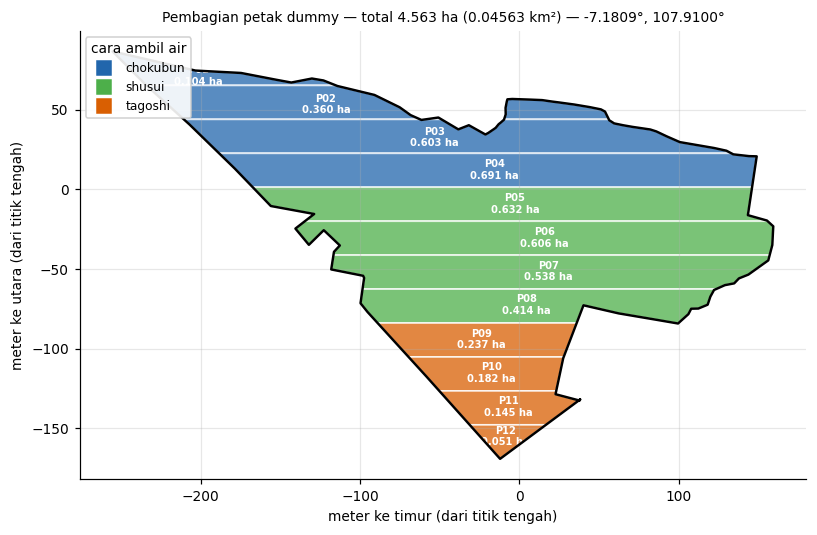

In [61]:
fig, ax = plt.subplots(figsize=(7.5, 6))
warna = {"chokubun": "#2166ac", "shusui": "#4daf4a", "tagoshi": "#d95f02"}

for poly, (_, r) in zip(petak_poly, petak.iterrows()):
    ax.add_patch(MplPolygon(poly, closed=True, facecolor=warna[r["cara_ambil_air"]],
                            edgecolor="white", linewidth=1.2, alpha=0.75))
    cx, cy = pusat_poligon(poly)
    ax.text(cx, cy, f"{r['id_petak']}\n{r['luas_ha']:.3f} ha",
            ha="center", va="center", fontsize=6.5, color="white", weight="bold")

ax.plot(np.append(X, X[0]), np.append(Y, Y[0]), color="black", lw=1.6, zorder=5)
for k, v in warna.items():
    ax.plot([], [], "s", color=v, label=k, markersize=9)
ax.legend(title="cara ambil air", loc="upper left", fontsize=8, framealpha=0.9)
ax.set_aspect("equal")
ax.set_xlabel("meter ke timur (dari titik tengah)")
ax.set_ylabel("meter ke utara (dari titik tengah)")
ax.set_title(f"Pembagian petak dummy — total {LUAS_HA:.3f} ha ({LUAS_KM2:.5f} km²) — "
             f"{lat0:.4f}°, {lon0:.4f}°", fontsize=9)
plt.tight_layout(); plt.show()

---
## 5. Data cuaca dummy

Musim tanam 110 hari. Cuaca dibuat menyerupai kondisi di paper Arif (musim kemarau),
disesuaikan sedikit untuk ketinggian ~693 m (agak lebih sejuk dari Wonogiri).

Hujan dibangkitkan dengan **rantai Markov** sederhana: peluang hari ini hujan tergantung
kemarin hujan atau tidak. Ini bikin hujannya menggerombol (beberapa hari berturut-turut),
seperti kejadian nyata — bukan tersebar acak merata.

`SEED` dikunci supaya hasilnya sama tiap kali dijalankan.

In [62]:
TANGGAL_TANAM = date(2026, 5, 15)
N_HARI        = 110

rng = np.random.default_rng(SEED)
hari = np.arange(N_HARI)
tanggal = [TANGGAL_TANAM + timedelta(days=int(d)) for d in hari]
maju = hari / (N_HARI - 1)                       # 0 di awal -> 1 di akhir musim

# Suhu (deg C) - naik perlahan menuju puncak kemarau
t_maks = 29.0 + 4.0*maju + rng.normal(0, 1.0, N_HARI)
t_min  = 18.0 + 2.0*maju + rng.normal(0, 0.8, N_HARI)
t_rata = (t_maks + t_min) / 2.0

# Radiasi matahari (MJ/m2/hari) - 15 -> 24, meniru Gambar 3 paper Arif
rs = np.clip(15.0 + 9.0*maju + rng.normal(0, 2.2, N_HARI), 5.0, 30.0)

# Hujan (mm/hari) - rantai Markov 2 keadaan + campuran ringan/lebat
#
# Kenapa campuran? Hujan tropis punya "ekor berat": kebanyakan gerimis, tapi
# sesekali ada guyuran besar. Kalau pakai satu sebaran eksponensial saja,
# hujan terbesar cuma ~15 mm dan jalur limpasan tidak pernah teruji.
P_BASAH_SETELAH_KERING = 0.15
P_BASAH_SETELAH_BASAH  = 0.45
RERATA_HUJAN_RINGAN_MM = 6.0
RERATA_HUJAN_LEBAT_MM  = 32.0
PELUANG_HUJAN_LEBAT    = 0.15

hujan, basah = np.zeros(N_HARI), False
for i in range(N_HARI):
    amb  = P_BASAH_SETELAH_BASAH if basah else P_BASAH_SETELAH_KERING
    amb *= (1.0 - 0.5*maju[i])                   # makin ke akhir makin kering
    basah = rng.random() < amb
    if basah:
        lebat = rng.random() < PELUANG_HUJAN_LEBAT
        hujan[i] = rng.exponential(RERATA_HUJAN_LEBAT_MM if lebat
                                   else RERATA_HUJAN_RINGAN_MM)
hujan = np.round(hujan, 1)
rs[hujan > 0] *= 0.75                            # hari hujan -> matahari terhalang

cuaca = pd.DataFrame({"hari": hari + 1, "tanggal": tanggal,
                      "t_maks": t_maks.round(2), "t_min": t_min.round(2),
                      "t_rata": t_rata.round(2), "rs_mj": rs.round(2),
                      "hujan_mm": hujan})

print(f"Musim tanam : {tanggal[0]}  s/d  {tanggal[-1]}   ({N_HARI} hari)")
print(f"Suhu rata2  : {t_rata.mean():.1f} C   (min {t_min.mean():.1f} / maks {t_maks.mean():.1f})")
print(f"Radiasi     : {rs.mean():.1f} MJ/m2/hari")
print(f"Hujan total : {hujan.sum():.1f} mm dalam {(hujan>0).sum()} hari hujan")
print(f"Hujan terbesar sehari: {hujan.max():.1f} mm")
cuaca.head()

Musim tanam : 2026-05-15  s/d  2026-09-01   (110 hari)
Suhu rata2  : 24.9 C   (min 18.8 / maks 31.0)
Radiasi     : 18.6 MJ/m2/hari
Hujan total : 215.8 mm dalam 19 hari hujan
Hujan terbesar sehari: 57.9 mm


,hari,tanggal,t_maks,t_min,t_rata,rs_mj,hujan_mm
0,1,2026-05-15,29.49,17.84,23.66,16.99,0.0
1,2,2026-05-16,27.58,19.95,23.76,13.43,0.0
2,3,2026-05-17,28.93,17.22,23.07,12.69,2.7
3,4,2026-05-18,28.01,18.19,23.10,13.81,7.3
4,5,2026-05-19,28.71,17.10,22.91,12.66,0.0


---
## 6. Hitung ETo — patokan penguapan dari cuaca

**ETo** = kalau lahan ini ditanami rumput standar, berapa mm air menguap per hari?
Murni soal cuaca, belum soal padi.

Rumus Hargreaves versi radiasi, persis persamaan (1) di paper Arif:

$$ ET_o = 0{,}0135 \,(T_{rata} + 17{,}78)\; R_s \left( \frac{238{,}8}{595{,}5 - 0{,}55\,T_{rata}} \right) $$

Bagian dalam kurung fungsinya **mengubah satuan radiasi** dari MJ/m²/hari menjadi
"setara mm air" — yaitu membagi dengan panas yang dibutuhkan untuk menguapkan air
(*panas laten*, sekitar 2,45 MJ per kg). Nilainya sekitar **0,41**.

Kenapa Hargreaves, bukan Penman-Monteith yang lebih akurat? Karena Hargreaves **cuma butuh
suhu + radiasi**. Penman-Monteith butuh angin, kelembapan, dan tekanan udara juga — jauh
lebih mahal kalau mau pasang di banyak titik.

In [63]:
def hitung_eto(t_rata, rs_mj):
    '''ETo (mm/hari) - Hargreaves berbasis radiasi, Arif et al. (2015) pers. (1).'''
    faktor_mm = 238.8 / (595.5 - 0.55*np.asarray(t_rata, float))   # MJ/m2 -> mm air
    return 0.0135 * (np.asarray(t_rata, float) + 17.78) * np.asarray(rs_mj, float) * faktor_mm

cuaca["eto_mm"] = hitung_eto(cuaca["t_rata"], cuaca["rs_mj"]).round(3)

print(f"ETo rata-rata : {cuaca['eto_mm'].mean():.2f} mm/hari")
print(f"ETo terendah  : {cuaca['eto_mm'].min():.2f} mm/hari")
print(f"ETo tertinggi : {cuaca['eto_mm'].max():.2f} mm/hari")
print(f"ETo awal musim: {cuaca['eto_mm'][:10].mean():.2f} mm/hari")
print(f"ETo akhir     : {cuaca['eto_mm'][-10:].mean():.2f} mm/hari")

print("\n--- Uji rumus terhadap angka di paper Arif ---")
for t, r, target in [(25.0, 15.0, 3.5), (25.0, 25.0, 6.0)]:
    hasil = float(hitung_eto(t, r))
    print(f"  T={t}C, Rs={r} MJ  ->  ETo = {hasil:.2f} mm/hari   "
          f"(paper menyebut ~{target})   selisih {abs(hasil-target):.2f}")

ETo rata-rata : 4.41 mm/hari
ETo terendah  : 2.23 mm/hari
ETo tertinggi : 6.69 mm/hari
ETo awal musim: 3.11 mm/hari
ETo akhir     : 5.59 mm/hari

--- Uji rumus terhadap angka di paper Arif ---
  T=25.0C, Rs=15.0 MJ  ->  ETo = 3.56 mm/hari   (paper menyebut ~3.5)   selisih 0.06
  T=25.0C, Rs=25.0 MJ  ->  ETo = 5.93 mm/hari   (paper menyebut ~6.0)   selisih 0.07


---
## 7. Kc dan fase pertumbuhan — dari patokan ke kebutuhan padi

**Kc** adalah angka pengali dari rumput patokan ke padi:

$$ ET_c = K_c \times ET_o $$

Nilai Kc di bawah diambil **langsung dari Tabel 1 paper Arif** (hasil pengukuran di
terasering Wonogiri), bukan dari tabel FAO. Alasannya: Kc hasil ukur di terasering Indonesia
lebih cocok untuk kasus kita daripada nilai FAO yang berasal dari kondisi standar.

| Fase | Kc genangan (FL) | Kc SRI | Kc standar FAO |
|---|---|---|---|
| Awal (*initial*) | 1,01 | 1,00 | 1,10 – 1,15 |
| Pertumbuhan (*development*) | 1,02 | 0,96 | 1,10 – 1,15 |
| Reproduktif (*mid-season*) | 1,09 | 1,02 | 1,10 – 1,30 |
| Pemasakan (*late*) | 1,05 | 1,04 | 0,95 – 1,05 |

Kc SRI lebih rendah karena tanahnya lebih kering → penguapan dari permukaan tanah lebih sedikit.

**Perhatian:** Kc di paper Arif dihitung *mundur* dari neraca air lapangan, jadi efek
kekurangan air sudah ikut terkandung di dalamnya. Karena itu di simulasi ini kita **tidak**
menambahkan faktor cekaman air lagi — nanti terhitung dua kali.

In [64]:
# Panjang fase (hari) - total harus = N_HARI
FASE = [("awal", 20), ("pertumbuhan", 30), ("reproduktif", 40), ("pemasakan", 20)]
assert sum(d for _, d in FASE) == N_HARI, "Total panjang fase harus sama dengan N_HARI"

KC = {"FL":  {"awal": 1.01, "pertumbuhan": 1.02, "reproduktif": 1.09, "pemasakan": 1.05},
      "SRI": {"awal": 1.00, "pertumbuhan": 0.96, "reproduktif": 1.02, "pemasakan": 1.04}}

# Aturan tinggi muka air per fase (mm, relatif permukaan tanah)
#   target  = diisi sampai setinggi ini
#   pemicu  = kalau turun sampai sini, mulai diairi lagi
#   hd      = tinggi lubang buang; kelebihan di atas ini melimpas keluar
ATURAN_TMA = {
    "FL":  {"awal": (20,  10, 50), "pertumbuhan": (20,  10, 50),
            "reproduktif": (10,   5, 40), "pemasakan": (10,   0, 40)},
    "SRI": {"awal": (10,   0, 40), "pertumbuhan": (10, -20, 40),
            "reproduktif": ( 5, -25, 30), "pemasakan": ( 0, -30, 30)},
}

fase_harian = np.concatenate([[nm]*d for nm, d in FASE])
cuaca["fase"] = fase_harian
for rez in ("FL", "SRI"):
    cuaca[f"kc_{rez}"]  = [KC[rez][f] for f in fase_harian]
    cuaca[f"etc_{rez}"] = (cuaca[f"kc_{rez}"] * cuaca["eto_mm"]).round(3)

ringkas = cuaca.groupby("fase", sort=False).agg(
    hari=("hari", "count"), eto=("eto_mm", "mean"),
    kc_FL=("kc_FL", "first"), etc_FL=("etc_FL", "mean"),
    kc_SRI=("kc_SRI", "first"), etc_SRI=("etc_SRI", "mean"),
    hujan=("hujan_mm", "sum")).round(3)
print(ringkas.to_string())
print(f"\nETc total semusim  FL  : {cuaca['etc_FL'].sum():7.1f} mm")
print(f"ETc total semusim  SRI : {cuaca['etc_SRI'].sum():7.1f} mm")
print(f"(paper Arif mencatat 517 mm untuk FL dan 496 mm untuk SRI)")

             hari    eto  kc_FL  etc_FL  kc_SRI  etc_SRI  hujan
fase                                                           
awal           20  3.268   1.01   3.301    1.00    3.268   98.0
pertumbuhan    30  4.076   1.02   4.158    0.96    3.913   84.5
reproduktif    40  4.722   1.09   5.147    1.02    4.816   25.7
pemasakan      20  5.435   1.05   5.707    1.04    5.653    7.6

ETc total semusim  FL  :   510.8 mm
ETc total semusim  SRI :   488.5 mm
(paper Arif mencatat 517 mm untuk FL dan 496 mm untuk SRI)


---
## 8. Simulasi neraca air per petak

Ini inti perhitungannya. Tiap hari, untuk tiap petak:

$$ h_{besok} = h_{hari\ ini} + \underbrace{Hujan + Irigasi}_{\text{masuk}} - \underbrace{ET_c - Perkolasi - Limpasan}_{\text{keluar}} $$

Semua dalam **mm**. `h` = tinggi muka air (TMA) relatif permukaan tanah.

**Aturan tiap komponen**

| Komponen | Aturan | Sumber |
|---|---|---|
| **ETc** | `Kc × ETo`, tiap hari | Arif |
| **Perkolasi** | `a × h × 86400` — sebanding tinggi genangan; saat tidak tergenang tetap jalan sebesar `PERK_KERING_RASIO` × laju penuh | Li, pers. (9) |
| **Limpasan** | kelebihan di atas `hd` langsung keluar hari itu juga | Li, pers. (7) |
| **Irigasi** | kalau `h < pemicu`, isi sampai `target` | logika kontrol WMS |

**Kenapa limpasan langsung habis dalam sehari?** Dicek dengan rumus ambang Li:
untuk kelebihan 2 cm di petak 500 m², waktu pengurasan cuma ± 3–4 jam. Jadi untuk
langkah waktu harian, "langsung keluar" itu wajar.

In [65]:
# Perkolasi saat sawah TIDAK tergenang, sebagai rasio dari laju saat tergenang penuh.
#
# Kenapa bukan nol? Waktu permukaan sawah kering, tanah di bawahnya MASIH JENUH
# dan tetap meneteskan air ke bawah. Kalau dipatok nol, SRI akan terlihat jauh
# lebih hemat daripada kenyataannya.
#
# Nilai ini adalah KETIDAKPASTIAN TERBESAR di seluruh notebook - lihat bagian 12.
PERK_KERING_RASIO = 0.60

def waktu_kuras_jam(kelebihan_m, hd_m, lebar_lubang_m, luas_m2):
    '''Perkiraan waktu menguras kelebihan air lewat lubang buang - Li pers. (7)-(8).'''
    if kelebihan_m <= 0:
        return 0.0
    Cd = 0.605 + 1.0/(1000*kelebihan_m) + 0.08*kelebihan_m/hd_m
    Qp = (2/3) * Cd * math.sqrt(2*9.81) * lebar_lubang_m * kelebihan_m**1.5   # m3/s
    return (kelebihan_m * luas_m2) / Qp / 3600.0

print("Cek asumsi 'limpasan habis dalam sehari':")
for lebih_cm in (1, 2, 5):
    jam = waktu_kuras_jam(lebih_cm/100, 0.04, 0.15, 500.0)
    print(f"  kelebihan {lebih_cm} cm di petak 500 m2, lubang 15 cm -> kuras {jam:5.1f} jam")
print("  -> semuanya < 24 jam, asumsi aman.")

Cek asumsi 'limpasan habis dalam sehari':
  kelebihan 1 cm di petak 500 m2, lubang 15 cm -> kuras   4.3 jam
  kelebihan 2 cm di petak 500 m2, lubang 15 cm -> kuras   3.2 jam
  kelebihan 5 cm di petak 500 m2, lubang 15 cm -> kuras   1.9 jam
  -> semuanya < 24 jam, asumsi aman.


In [66]:
def simulasi_petak(cuaca, rezim, perk_per_mm, h_awal=20.0, aturan=None,
                   rasio_kering=None):
    '''Neraca air harian satu petak. Semua satuan mm.'''
    aturan = ATURAN_TMA if aturan is None else aturan
    rasio_kering = PERK_KERING_RASIO if rasio_kering is None else rasio_kering
    n = len(cuaca)
    h = float(h_awal)
    kol = {k: np.zeros(n) for k in
           ("tma", "irigasi", "etc", "perkolasi", "limpasan", "hujan_mm")}

    etc_all = cuaca[f"etc_{rezim}"].to_numpy()
    for i in range(n):
        fase = cuaca["fase"].iat[i]
        target, pemicu, hd = aturan[rezim][fase]

        # --- air masuk ---
        hujan = float(cuaca["hujan_mm"].iat[i])
        h += hujan

        irigasi = 0.0
        if h < pemicu:                       # TMA di bawah ambang -> airi
            irigasi = target - h
            h = float(target)

        # --- air keluar ---
        etc = float(etc_all[i])
        perk = perk_per_mm*h if h > 0 else perk_per_mm*hd*rasio_kering
        h -= (etc + perk)

        limpasan = 0.0
        if h > hd:                           # kelebihan melimpas lewat lubang buang
            limpasan = h - hd
            h = float(hd)

        h = max(h, -150.0)                   # batas bawah wajar tanah sawah
        for k, v in zip(kol, (h, irigasi, etc, perk, limpasan, hujan)):
            kol[k][i] = v

    out = pd.DataFrame(kol)
    out.insert(0, "hari", cuaca["hari"].to_numpy())
    out.insert(1, "tanggal", cuaca["tanggal"].to_numpy())
    out.insert(2, "fase", cuaca["fase"].to_numpy())
    return out


harian, ringkasan = [], []
for _, p in petak.iterrows():
    for rezim in ("FL", "SRI"):
        sim = simulasi_petak(cuaca, rezim, p["perk_per_mm"])
        sim.insert(0, "rezim", rezim)
        sim.insert(0, "id_petak", p["id_petak"])
        harian.append(sim)

        luas = p["luas_m2"]
        mm2m3 = luas / 1000.0                # 1 mm di luas A m2 = A/1000 m3
        ringkasan.append({
            "id_petak": p["id_petak"], "rezim": rezim,
            "cara_ambil_air": p["cara_ambil_air"],
            "luas_ha": p["luas_ha"], "luas_m2": luas,
            "hujan_mm":     sim["hujan_mm"].sum(),
            "irigasi_mm":   sim["irigasi"].sum(),
            "etc_mm":       sim["etc"].sum(),
            "perkolasi_mm": sim["perkolasi"].sum(),
            "limpasan_mm":  sim["limpasan"].sum(),
            "irigasi_m3":   sim["irigasi"].sum() * mm2m3,
            "etc_m3":       sim["etc"].sum() * mm2m3,
            "perkolasi_m3": sim["perkolasi"].sum() * mm2m3,
            "limpasan_m3":  sim["limpasan"].sum() * mm2m3,
            "tma_min_mm":   sim["tma"].min(),
            "tma_maks_mm":  sim["tma"].max(),
            "hari_diairi":  int((sim["irigasi"] > 0).sum()),
            "irigasi_maks_harian_mm": sim["irigasi"].max(),
        })

harian    = pd.concat(harian, ignore_index=True)
ringkasan = pd.DataFrame(ringkasan)
print(f"Simulasi selesai: {len(petak)} petak x 2 rezim x {N_HARI} hari = {len(harian):,} baris")
ringkasan.head(6).round(1)

Simulasi selesai: 12 petak x 2 rezim x 110 hari = 2,640 baris


,id_petak,rezim,cara_ambil_air,luas_ha,luas_m2,hujan_mm,irigasi_mm,etc_mm,perkolasi_mm,limpasan_mm,irigasi_m3,etc_m3,perkolasi_m3,limpasan_m3,tma_min_mm,tma_maks_mm,hari_diairi,irigasi_maks_harian_mm
0,P01,FL,chokubun,0.1,1042.8,215.8,388.0,510.8,70.3,37.7,404.6,532.6,73.4,39.4,-5.6,50.0,45,15.6
1,P01,SRI,chokubun,0.1,1042.8,215.8,337.4,488.5,79.6,38.0,351.8,509.4,83.0,39.6,-35.0,40.0,11,35.0
2,P02,FL,chokubun,0.4,3605.0,215.8,403.0,510.8,83.9,39.4,1452.8,1841.3,302.3,141.9,-5.7,50.0,47,15.7
3,P02,SRI,chokubun,0.4,3605.0,215.8,350.1,488.5,95.2,35.8,1262.3,1760.9,343.1,129.2,-36.1,40.0,11,36.3
4,P03,FL,chokubun,0.6,6031.8,215.8,403.4,510.8,93.4,37.4,2433.3,3080.8,563.4,225.9,-4.3,50.0,47,15.1
5,P03,SRI,chokubun,0.6,6031.8,215.8,370.1,488.5,103.3,34.6,2232.3,2946.3,623.3,208.7,-34.0,40.0,12,35.7


---
## 9. Kebutuhan air

Tiga angka yang berbeda dan sering tertukar:

| Istilah | Artinya | Satuan |
|---|---|---|
| **NFR** (*Net Field Requirement*) | Kebutuhan **bersih di petak** — yang benar-benar dipakai sawah | mm/hari |
| **DR** (*Diversion Requirement*) | Yang harus **diambil dari bendung** — sudah termasuk bocor di saluran | l/detik/ha |
| **Debit total** | DR × luas total | l/detik atau m³/detik |

Rumus konversi (KP-01):

$$ DR\ \left[\tfrac{l}{s \cdot ha}\right] = \frac{NFR\ \left[\tfrac{mm}{hari}\right]}{8{,}64 \times e} $$

**Dari mana angka 8,64?** 1 mm/hari di 1 ha = 10.000 liter / 86.400 detik = 0,1157 l/detik.
Dan 1 ÷ 0,1157 = **8,64**. Jadi itu cuma angka konversi satuan, bukan sesuatu yang misterius.

`e` = efisiensi irigasi keseluruhan. Nilai lazim KP-01: saluran primer 0,90 × sekunder 0,90 ×
tersier 0,80 ≈ **0,65**. Artinya dari 100 liter yang diambil di bendung, cuma 65 liter sampai ke sawah.

In [67]:
EFISIENSI_IRIGASI = 0.65        # KP-01: 0,90 x 0,90 x 0,80
MM_HARI_KE_LDETIK_HA = 1/8.64   # = 0,1157

def ke_l_detik_ha(nfr_mm_hari, efisiensi=EFISIENSI_IRIGASI):
    return nfr_mm_hari / (8.64 * efisiensi)

keb = ringkasan.copy()
keb["nfr_rata_mm_hari"] = keb["irigasi_mm"] / N_HARI
keb["dr_l_detik_ha"]    = ke_l_detik_ha(keb["nfr_rata_mm_hari"])
keb["debit_l_detik"]    = keb["dr_l_detik_ha"] * keb["luas_ha"]

tabel = (keb[["id_petak", "rezim", "cara_ambil_air", "luas_ha", "irigasi_mm",
              "irigasi_m3", "nfr_rata_mm_hari", "dr_l_detik_ha", "debit_l_detik"]]
         .sort_values(["id_petak", "rezim"]))
print(tabel.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

id_petak rezim cara_ambil_air  luas_ha  irigasi_mm  irigasi_m3  nfr_rata_mm_hari  dr_l_detik_ha  debit_l_detik
     P01    FL       chokubun    0.104     387.965     404.566             3.527          0.628          0.065
     P01   SRI       chokubun    0.104     337.403     351.840             3.067          0.546          0.057
     P02    FL       chokubun    0.360     403.007   1,452.834             3.664          0.652          0.235
     P02   SRI       chokubun    0.360     350.140   1,262.251             3.183          0.567          0.204
     P03    FL       chokubun    0.603     403.419   2,433.347             3.667          0.653          0.394
     P03   SRI       chokubun    0.603     370.087   2,232.297             3.364          0.599          0.361
     P04    FL       chokubun    0.691     376.497   2,602.309             3.423          0.609          0.421
     P04   SRI       chokubun    0.691     321.999   2,225.622             2.927          0.521          0.360
 

In [68]:
print("=" * 66)
print("        KEBUTUHAN AIR SELURUH LAHAN  (%.4f ha)" % LUAS_HA)
print("=" * 66)
for rezim in ("FL", "SRI"):
    s = keb[keb["rezim"] == rezim]
    irigasi_mm = s["irigasi_m3"].sum() / (LUAS_M2/1000.0)      # rata-rata tertimbang luas
    nfr  = irigasi_mm / N_HARI
    dr   = ke_l_detik_ha(nfr)
    print(f"\n  Rezim {rezim}")
    print(f"    Irigasi semusim        : {irigasi_mm:8.1f} mm  = {s['irigasi_m3'].sum():10,.0f} m3")
    print(f"    NFR rata-rata          : {nfr:8.2f} mm/hari")
    print(f"    DR (di bendung, e={EFISIENSI_IRIGASI})  : {dr:8.3f} l/detik/ha")
    print(f"    Debit total dibutuhkan : {dr*LUAS_HA:8.2f} l/detik  = {dr*LUAS_HA/1000:.4f} m3/detik")
    print(f"    Hari perlu diairi      : {s['hari_diairi'].mean():8.1f} hari dari {N_HARI}")
print("\n" + "-" * 66)
print("  Pembanding paper Arif (Wonogiri): FL 536 mm, SRI 518 mm per musim")
print("=" * 66)

        KEBUTUHAN AIR SELURUH LAHAN  (4.5627 ha)

  Rezim FL
    Irigasi semusim        :    443.3 mm  =     20,226 m3
    NFR rata-rata          :     4.03 mm/hari
    DR (di bendung, e=0.65)  :    0.718 l/detik/ha
    Debit total dibutuhkan :     3.27 l/detik  = 0.0033 m3/detik
    Hari perlu diairi      :     48.8 hari dari 110

  Rezim SRI
    Irigasi semusim        :    407.3 mm  =     18,585 m3
    NFR rata-rata          :     3.70 mm/hari
    DR (di bendung, e=0.65)  :    0.659 l/detik/ha
    Debit total dibutuhkan :     3.01 l/detik  = 0.0030 m3/detik
    Hari perlu diairi      :     12.2 hari dari 110

------------------------------------------------------------------
  Pembanding paper Arif (Wonogiri): FL 536 mm, SRI 518 mm per musim


### Kebutuhan penyiapan lahan — penentu debit puncak

Ketiga paper di `docs/` **tidak** membahas ini, padahal justru fase inilah yang menentukan
ukuran saluran dan pintu air. Sebelum tanam, sawah harus dijenuhkan dan digenangi untuk
digaru — butuh air jauh lebih banyak daripada saat padi sudah tumbuh.

Rumus **van de Goor & Zijlstra** (dipakai KP-01):

$$ IR = \frac{M \, e^{k}}{e^{k} - 1}, \qquad k = \frac{M \cdot T}{S} $$

- `M` = kehilangan air di sawah yang sudah dijenuhkan = `Eo + P` (mm/hari)
- `Eo` = penguapan air terbuka ≈ 1,1 × ETo
- `P`  = perkolasi (mm/hari)
- `S`  = air untuk menjenuhkan tanah + genangan awal (mm), lazimnya 250–300
- `T`  = lama penyiapan lahan (hari), lazimnya 30–45

In [69]:
def kebutuhan_penyiapan_lahan(eto, perkolasi, S=250.0, T=30.0):
    '''IR (mm/hari) - van de Goor & Zijlstra, KP-01.'''
    M = 1.1*eto + perkolasi
    k = M * T / S
    return M * math.exp(k) / (math.exp(k) - 1.0)

eto_awal = float(cuaca["eto_mm"][:30].mean())
print(f"ETo rata-rata 30 hari pertama: {eto_awal:.2f} mm/hari\n")

baris_pl = []
for _, p in petak.iterrows():
    perk = p["perk_per_mm"] * 50.0                       # genangan 5 cm saat penyiapan
    ir   = kebutuhan_penyiapan_lahan(eto_awal, perk)
    baris_pl.append({"id_petak": p["id_petak"], "cara_ambil_air": p["cara_ambil_air"],
                     "luas_ha": p["luas_ha"], "perkolasi_mm_hari": perk,
                     "IR_mm_hari": ir, "DR_l_detik_ha": ke_l_detik_ha(ir),
                     "debit_l_detik": ke_l_detik_ha(ir)*p["luas_ha"]})
pl = pd.DataFrame(baris_pl)
print(pl.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

ir_maks = pl["IR_mm_hari"].max()
dr_maks = pl["DR_l_detik_ha"].max()
nfr_tumbuh = keb[keb.rezim=="FL"]["nfr_rata_mm_hari"].mean()
print(f"\n{'='*62}")
print(f"  DEBIT PUNCAK (penyiapan lahan) : {dr_maks:.3f} l/detik/ha")
print(f"  Debit total saat penyiapan     : {pl['debit_l_detik'].sum():.2f} l/detik "
      f"= {pl['debit_l_detik'].sum()/1000:.4f} m3/detik")
print(f"  Bandingkan fase tumbuh (FL)    : {ke_l_detik_ha(nfr_tumbuh):.3f} l/detik/ha")
print(f"  -> penyiapan lahan butuh {ir_maks/max(nfr_tumbuh,0.01):.1f}x lebih besar")
print(f"  SALURAN HARUS DIRANCANG UNTUK ANGKA PUNCAK INI, bukan rata-rata.")
print("="*62)

ETo rata-rata 30 hari pertama: 3.49 mm/hari

id_petak cara_ambil_air  luas_ha  perkolasi_mm_hari  IR_mm_hari  DR_l_detik_ha  debit_l_detik
     P01       chokubun    0.104              1.995      11.587          2.063          0.215
     P02       chokubun    0.360              2.416      11.847          2.110          0.760
     P03       chokubun    0.603              2.709      12.031          2.142          1.292
     P04       chokubun    0.691              1.544      11.311          2.014          1.392
     P05         shusui    0.632              6.860      14.795          2.634          1.664
     P06         shusui    0.606              5.322      13.735          2.446          1.483
     P07         shusui    0.538              5.117      13.597          2.421          1.302
     P08         shusui    0.414              6.805      14.757          2.628          1.088
     P09        tagoshi    0.237              1.602      11.346          2.020          0.479
     P10       

---
## 10. Water loss — ke mana air pergi

Air yang masuk (hujan + irigasi) keluar lewat **tiga pintu**:

| Jalur keluar | Istilah | Hilang betulan? |
|---|---|---|
| **Menguap** dari genangan + lewat daun padi | ETc | Ya — tapi ini yang **produktif** (bikin padi tumbuh) |
| **Meresap** ke bawah lewat dasar sawah | Perkolasi | Sebagian; bisa mengisi air tanah |
| **Mengalir keluar** lewat lubang buang | Limpasan | Bisa dipakai lagi petak di bawahnya |

Yang benar-benar merugikan adalah **limpasan berlebih** — air terbuang tanpa sempat dipakai,
dan **ikut membawa pupuk** (nitrogen) keluar dari petak.

Terakhir kita cek **penutupan neraca** (*closure*): masuk − keluar − perubahan simpanan
harus ≈ 0. Kalau tidak nol, ada kesalahan hitung.

In [70]:
wl = ringkasan.copy()
wl["masuk_mm"]  = wl["hujan_mm"] + wl["irigasi_mm"]
wl["keluar_mm"] = wl["etc_mm"] + wl["perkolasi_mm"] + wl["limpasan_mm"]
wl["delta_simpanan_mm"] = wl["masuk_mm"] - wl["keluar_mm"]

# Persentase dihitung terhadap TOTAL KELUAR supaya selalu berjumlah 100%.
# Kalau dibagi "masuk", angkanya bisa lewat 100% ketika sawah menguras
# simpanan airnya sendiri - membingungkan waktu dibaca.
for k in ("etc", "perkolasi", "limpasan"):
    wl[f"{k}_pct"] = 100 * wl[f"{k}_mm"] / wl["keluar_mm"]

print("=" * 78)
print("            RINCIAN WATER LOSS  (rata-rata seluruh petak)")
print("=" * 78)
for rezim in ("FL", "SRI"):
    s = wl[wl["rezim"] == rezim]
    m3 = {k: s[f"{k}_m3"].sum() for k in ("etc", "perkolasi", "limpasan")}
    tot_m3 = sum(m3.values())
    print(f"\n  Rezim {rezim}   (air masuk {s['masuk_mm'].mean():.0f} mm, "
          f"perubahan simpanan {s['delta_simpanan_mm'].mean():+.0f} mm)")
    print(f"    {'jalur':<26}{'mm':>9}{'m3':>12}{'% dari keluar':>16}")
    print("    " + "-" * 63)
    for nama, k in [("Menguap (ETc)", "etc"), ("Meresap (perkolasi)", "perkolasi"),
                    ("Mengalir keluar (limpasan)", "limpasan")]:
        print(f"    {nama:<26}{s[f'{k}_mm'].mean():>9.1f}{m3[k]:>12,.0f}{s[f'{k}_pct'].mean():>15.1f}%")
    print("    " + "-" * 63)
    print(f"    {'TOTAL KELUAR':<26}{s['keluar_mm'].mean():>9.1f}{tot_m3:>12,.0f}{100.0:>15.1f}%")
print("=" * 78)

            RINCIAN WATER LOSS  (rata-rata seluruh petak)

  Rezim FL   (air masuk 643 mm, perubahan simpanan -18 mm)
    jalur                            mm          m3   % dari keluar
    ---------------------------------------------------------------
    Menguap (ETc)                 510.8      23,304           77.8%
    Meresap (perkolasi)           115.1       6,148           16.7%
    Mengalir keluar (limpasan)     35.4       1,528            5.5%
    ---------------------------------------------------------------
    TOTAL KELUAR                  661.3      30,980          100.0%

  Rezim SRI   (air masuk 601 mm, perubahan simpanan -48 mm)
    jalur                            mm          m3   % dari keluar
    ---------------------------------------------------------------
    Menguap (ETc)                 488.5      22,287           75.9%
    Meresap (perkolasi)           127.2       6,773           18.8%
    Mengalir keluar (limpasan)     33.7       1,451            5.3%
    -

In [71]:
# --- cek penutupan neraca air per petak ---
cek = []
for (pid, rez), g in harian.groupby(["id_petak", "rezim"], sort=False):
    tma0 = 20.0                                     # h_awal di simulasi
    masuk  = g["hujan_mm"].sum() + g["irigasi"].sum()
    keluar = g["etc"].sum() + g["perkolasi"].sum() + g["limpasan"].sum()
    d_simpanan = g["tma"].iloc[-1] - tma0
    cek.append({"id_petak": pid, "rezim": rez, "masuk_mm": masuk, "keluar_mm": keluar,
                "delta_simpanan_mm": d_simpanan, "sisa_mm": masuk - keluar - d_simpanan})
cek = pd.DataFrame(cek)

galat = cek["sisa_mm"].abs().max()
print(cek.head(6).round(3).to_string(index=False))
print(f"\nGalat penutupan terbesar: {galat:.6f} mm")
print("NERACA TERTUTUP - tidak ada air yang hilang di perhitungan." if galat < 1e-6
      else "PERIKSA - neraca tidak tertutup, ada bug.")

id_petak rezim  masuk_mm  keluar_mm  delta_simpanan_mm  sisa_mm
     P01    FL   603.765    618.842            -15.077      0.0
     P01   SRI   553.203    605.972            -52.769      0.0
     P02    FL   618.807    633.968            -15.161     -0.0
     P02   SRI   565.940    619.468            -53.527      0.0
     P03    FL   619.219    641.599            -22.381     -0.0
     P03   SRI   585.887    626.393            -40.505      0.0

Galat penutupan terbesar: 0.000000 mm
NERACA TERTUTUP - tidak ada air yang hilang di perhitungan.


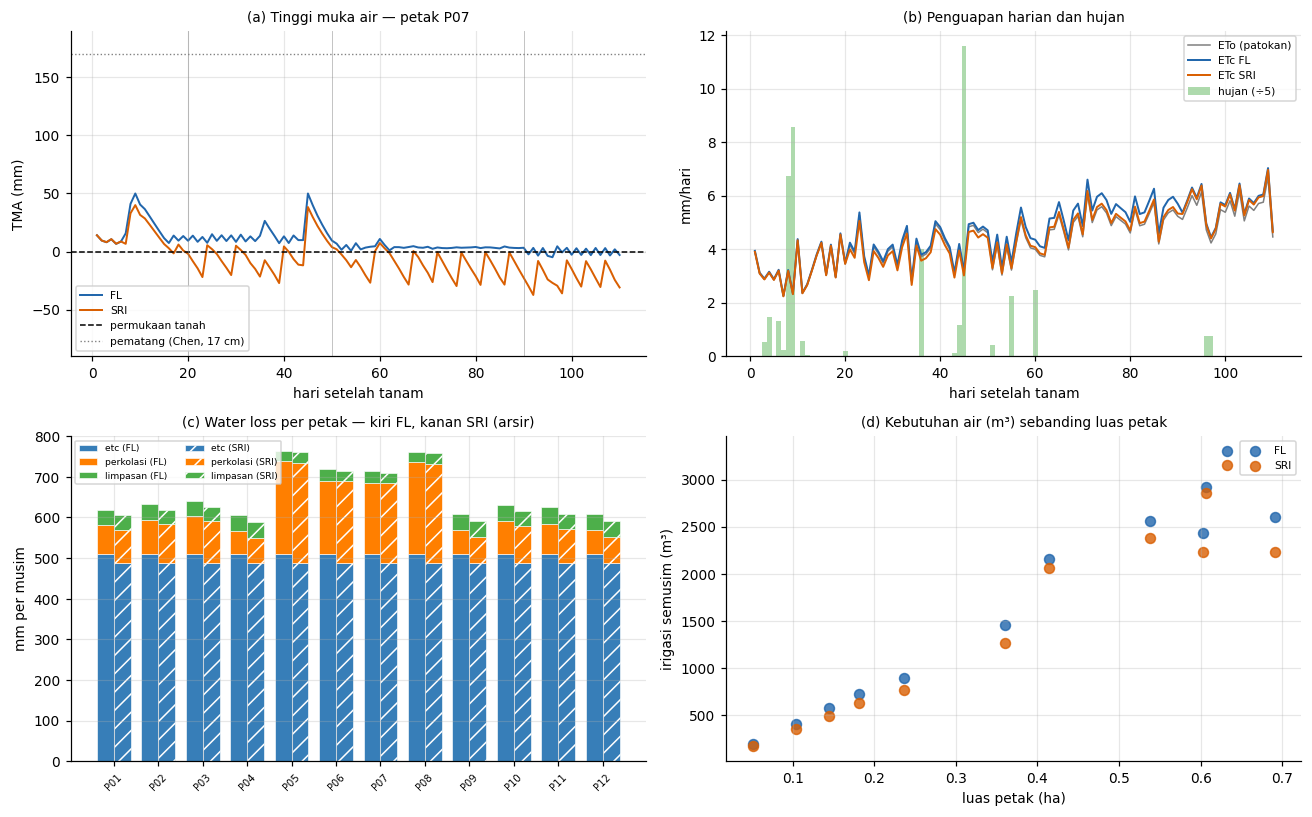

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))

# (a) TMA sepanjang musim - contoh satu petak
pid = petak["id_petak"].iloc[len(petak)//2]
ax = axes[0, 0]
for rezim, w in (("FL", "#2166ac"), ("SRI", "#d95f02")):
    g = harian[(harian.id_petak == pid) & (harian.rezim == rezim)]
    ax.plot(g["hari"], g["tma"], lw=1.3, color=w, label=rezim)
ax.axhline(0, color="black", lw=1.0, ls="--", label="permukaan tanah")
ax.axhline(170, color="grey", lw=0.9, ls=":", label="pematang (Chen, 17 cm)")
batas_fase = np.cumsum([d for _, d in FASE])[:-1]
for b in batas_fase:
    ax.axvline(b, color="grey", lw=0.6, alpha=0.5)
ax.set_title(f"(a) Tinggi muka air — petak {pid}", fontsize=9)
ax.set_xlabel("hari setelah tanam"); ax.set_ylabel("TMA (mm)")
ax.legend(fontsize=7); ax.set_ylim(-90, 190)

# (b) ETo dan ETc
ax = axes[0, 1]
ax.plot(cuaca["hari"], cuaca["eto_mm"], lw=1.0, color="grey", label="ETo (patokan)")
ax.plot(cuaca["hari"], cuaca["etc_FL"],  lw=1.3, color="#2166ac", label="ETc FL")
ax.plot(cuaca["hari"], cuaca["etc_SRI"], lw=1.3, color="#d95f02", label="ETc SRI")
ax.bar(cuaca["hari"], cuaca["hujan_mm"]/5, color="#4daf4a", alpha=0.45, width=1.0,
       label="hujan (÷5)")
ax.set_title("(b) Penguapan harian dan hujan", fontsize=9)
ax.set_xlabel("hari setelah tanam"); ax.set_ylabel("mm/hari"); ax.legend(fontsize=7)

# (c) Water loss bertumpuk
ax = axes[1, 0]
lebar, xs = 0.38, np.arange(len(petak))
for j, (rezim, hatch) in enumerate([("FL", ""), ("SRI", "//")]):
    s = wl[wl.rezim == rezim].set_index("id_petak").loc[petak["id_petak"]]
    bawah = np.zeros(len(s))
    for k, w in [("etc", "#377eb8"), ("perkolasi", "#ff7f00"), ("limpasan", "#4daf4a")]:
        ax.bar(xs + (j-0.5)*lebar, s[f"{k}_mm"], lebar, bottom=bawah, color=w,
               hatch=hatch, edgecolor="white", linewidth=0.4,
               label=f"{k} ({rezim})")
        bawah += s[f"{k}_mm"].to_numpy()
ax.set_xticks(xs); ax.set_xticklabels(petak["id_petak"], rotation=45, fontsize=6.5)
ax.set_title("(c) Water loss per petak — kiri FL, kanan SRI (arsir)", fontsize=9)
ax.set_ylabel("mm per musim")
ax.legend(fontsize=6, ncol=2, loc="upper left")

# (d) Kebutuhan air vs luas
ax = axes[1, 1]
for rezim, w in (("FL", "#2166ac"), ("SRI", "#d95f02")):
    s = keb[keb.rezim == rezim]
    ax.scatter(s["luas_ha"], s["irigasi_m3"], s=42, color=w, alpha=0.8, label=rezim)
ax.set_title("(d) Kebutuhan air (m³) sebanding luas petak", fontsize=9)
ax.set_xlabel("luas petak (ha)"); ax.set_ylabel("irigasi semusim (m³)"); ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

---
## 11. Peta overlay — hasil di atas citra satelit

Sekarang hasil hitungan ditempelkan ke peta sungguhan supaya kelihatan petak mana
yang boros dan mana yang hemat.

**Citra dasar** diambil dari Esri World Imagery (layanan tile publik) pada zoom 18
≈ 0,59 m per piksel. Tile disimpan di `note/output/tiles/` — jadi dijalankan ulang
tidak mengunduh lagi.

Kalau jaringan tidak tersedia, peta tetap tergambar, hanya **tanpa citra satelit**
di belakangnya. Notebook tidak akan gagal karena ini.

In [73]:
# ================= pengambil tile peta (dengan cache lokal) =================
import io as _io, socket, urllib.request
import matplotlib.image as mpimg
import matplotlib.patheffects as pe

TILE_URL = ("https://server.arcgisonline.com/ArcGIS/rest/services/"
            "World_Imagery/MapServer/tile/{z}/{y}/{x}")
KREDIT   = "Citra: Esri, Maxar, Earthstar Geographics"
TILE_DIR = OUT_DIR / "tiles"; TILE_DIR.mkdir(exist_ok=True)
ZOOM     = 18
MAX_TILE = 64                      # pagar pengaman, jangan membanjiri server

def lonlat_ke_piksel(lon, lat, z):
    '''Web Mercator: derajat -> piksel global (256 piksel per tile).'''
    n = 256 * 2**z
    return ((lon + 180.0)/360.0*n,
            (1.0 - math.asinh(math.tan(math.radians(lat)))/math.pi)/2.0*n)

def piksel_ke_lonlat(px, py, z):
    n = 256 * 2**z
    return (px/n*360.0 - 180.0,
            math.degrees(math.atan(math.sinh(math.pi*(1.0 - 2.0*py/n)))))

def ambil_tile(z, x, y, timeout=20):
    '''Satu tile. Dari cache kalau sudah pernah diunduh.'''
    berkas = TILE_DIR / f"{z}_{x}_{y}.jpg"
    if berkas.exists():
        return mpimg.imread(berkas)
    req = urllib.request.Request(TILE_URL.format(z=z, x=x, y=y), headers={
        "User-Agent": "WMS-AgrinIrigation/1.0 (notebook riset lokal)"})
    with urllib.request.urlopen(req, timeout=timeout) as r:
        data = r.read()
    berkas.write_bytes(data)
    return mpimg.imread(_io.BytesIO(data), format="jpeg")

def susun_basemap(lon, lat, z=ZOOM, margin=0.15):
    '''Rangkai mosaik tile penutup lahan -> (gambar, extent dalam meter lokal).'''
    dlon = (lon.max()-lon.min())*margin; dlat = (lat.max()-lat.min())*margin
    px0, py0 = lonlat_ke_piksel(lon.min()-dlon, lat.max()+dlat, z)
    px1, py1 = lonlat_ke_piksel(lon.max()+dlon, lat.min()-dlat, z)
    tx0, ty0, tx1, ty1 = int(px0//256), int(py0//256), int(px1//256), int(py1//256)

    n_tile = (tx1-tx0+1)*(ty1-ty0+1)
    if n_tile > MAX_TILE:
        raise RuntimeError(f"butuh {n_tile} tile (batas {MAX_TILE}) - turunkan ZOOM")

    kanvas = np.zeros(((ty1-ty0+1)*256, (tx1-tx0+1)*256, 3), dtype=np.uint8)
    for ty in range(ty0, ty1+1):
        for tx in range(tx0, tx1+1):
            ubin = ambil_tile(z, tx, ty)
            if ubin.dtype != np.uint8:
                ubin = (np.clip(ubin, 0, 1)*255).astype(np.uint8)
            kanvas[(ty-ty0)*256:(ty-ty0+1)*256,
                   (tx-tx0)*256:(tx-tx0+1)*256] = ubin[:, :, :3]

    lo_ki, la_at = piksel_ke_lonlat(tx0*256,     ty0*256,     z)
    lo_ka, la_ba = piksel_ke_lonlat((tx1+1)*256, (ty1+1)*256, z)
    extent = [(lo_ki - lon0)*M_PER_DEG_LON, (lo_ka - lon0)*M_PER_DEG_LON,
              (la_ba - lat0)*M_PER_DEG_LAT, (la_at - lat0)*M_PER_DEG_LAT]
    return kanvas, extent, n_tile

BASEMAP = EXTENT = None
try:
    socket.setdefaulttimeout(25)
    BASEMAP, EXTENT, n_tile = susun_basemap(lon, lat)
    skala = 40075016.686*math.cos(math.radians(lat0))/2**ZOOM/256
    print(f"Basemap siap : {BASEMAP.shape[1]} x {BASEMAP.shape[0]} piksel "
          f"dari {n_tile} tile (zoom {ZOOM})")
    print(f"Skala        : {skala:.2f} m per piksel")
    print(f"Cache        : {TILE_DIR}")
    print(f"{KREDIT}")
except Exception as e:
    print(f"Basemap TIDAK tersedia -> {type(e).__name__}: {e}")
    print("Peta tetap digambar, hanya tanpa citra satelit di belakangnya.")

Basemap siap : 1280 x 1024 piksel dari 20 tile (zoom 18)
Skala        : 0.59 m per piksel
Cache        : d:\WMS_AgrinIrigation\note\output\tiles
Citra: Esri, Maxar, Earthstar Geographics


In [74]:
# Perbandingan lebar:tinggi peta. Dipakai untuk menghitung tinggi gambar
# supaya colorbar menempel rapat ke peta, bukan mengambang jauh di kanan.
ASPEK_PETA = ((X.max()+32) - (X.min()-32)) / ((Y.max()+32) - (Y.min()-38))

def ukuran_peta(n_kolom, lebar_total=18.0, porsi_peta=0.82, ruang_judul=0.9):
    '''figsize yang pas untuk n peta bersebelahan.'''
    lebar_peta = porsi_peta * lebar_total / n_kolom
    return (lebar_total, lebar_peta/ASPEK_PETA + ruang_judul)

def batang_skala(ax, panjang_m=100):
    '''Batang skala di pojok kiri bawah peta.'''
    x0 = X.min() - 20; y0 = Y.min() - 26
    ax.plot([x0, x0+panjang_m], [y0, y0], color="white", lw=3.5, solid_capstyle="butt",
            path_effects=[pe.withStroke(linewidth=5.5, foreground="black")], zorder=8)
    ax.text(x0 + panjang_m/2, y0 + 7, f"{panjang_m} m", ha="center", va="bottom",
            fontsize=7, color="white", weight="bold", zorder=8,
            path_effects=[pe.withStroke(linewidth=2, foreground="black")])

def peta_petak(nilai, judul, satuan, cmap="YlOrRd", fmt="{:.0f}", ax=None,
               tampil_angka=True, skala=True, vmin=None, vmax=None):
    '''Petak diwarnai menurut `nilai` (Series ber-index id_petak), di atas basemap.'''
    if ax is None:
        _, ax = plt.subplots(figsize=(7.4, 6.2))
    if BASEMAP is not None:
        ax.imshow(BASEMAP, extent=EXTENT, origin="upper", interpolation="bilinear",
                  zorder=0)
    else:
        ax.set_facecolor("#e8e8e8")

    v = np.array([float(nilai[r["id_petak"]]) for _, r in petak.iterrows()])
    # vmin/vmax dipatok = skala warna TIDAK meregang mengikuti data. Penting kalau
    # sebarannya sempit - kalau dibiarkan otomatis, beda 2 mm bisa tampak dramatis.
    norm = plt.Normalize(v.min() if vmin is None else vmin,
                         v.max() if vmax is None else vmax)
    cm   = plt.get_cmap(cmap)

    for poly, val in zip(petak_poly, v):
        ax.add_patch(MplPolygon(poly, closed=True, facecolor=cm(norm(val)),
                                edgecolor="white", linewidth=1.0, alpha=0.75, zorder=2))
        if tampil_angka:
            cx, cy = pusat_poligon(poly)
            ax.text(cx, cy, fmt.format(val), ha="center", va="center", fontsize=6.2,
                    color="white", weight="bold", zorder=4,
                    path_effects=[pe.withStroke(linewidth=1.7, foreground="black")])

    ax.plot(np.append(X, X[0]), np.append(Y, Y[0]), color="#ffe400", lw=1.8, zorder=5)

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cm); sm.set_array([])
    cb = plt.colorbar(sm, ax=ax, fraction=0.043, pad=0.02)
    cb.set_label(satuan, fontsize=8); cb.ax.tick_params(labelsize=7)

    if skala:
        batang_skala(ax)
    ax.set_xlim(X.min()-32, X.max()+32); ax.set_ylim(Y.min()-38, Y.max()+32)
    ax.set_aspect("equal"); ax.set_title(judul, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    return ax

print("Fungsi peta siap: peta_petak(nilai, judul, satuan, cmap)")

Fungsi peta siap: peta_petak(nilai, judul, satuan, cmap)


### 11a. Peta dasar — luas dan cara ambil air

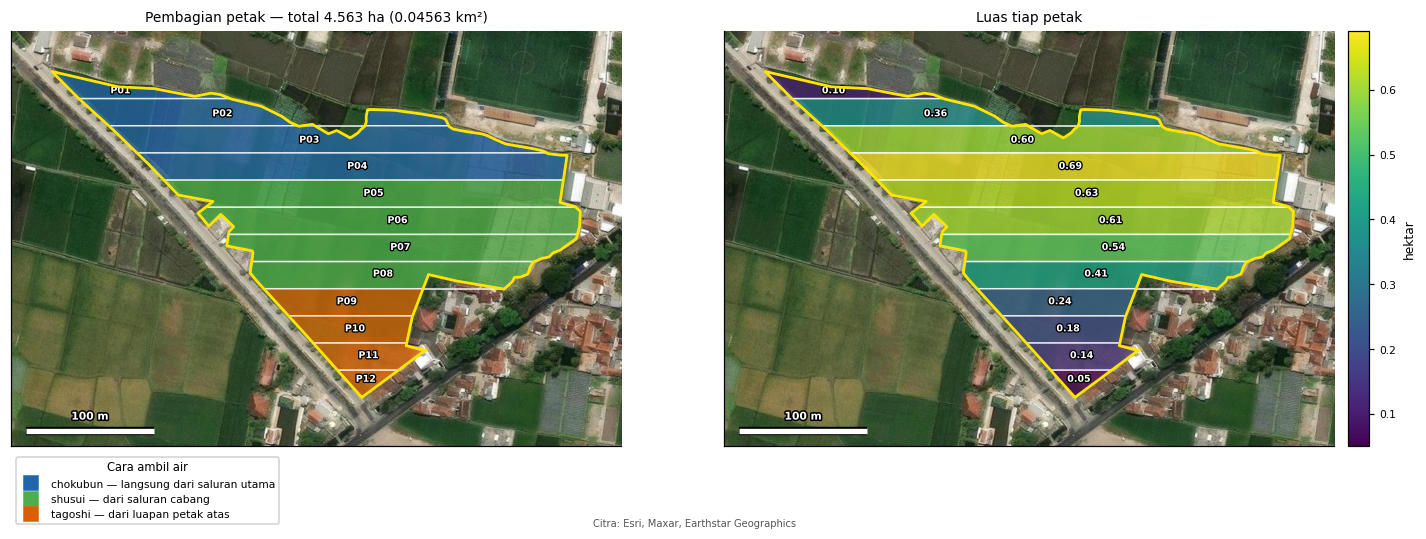

In [75]:
fig, axes = plt.subplots(1, 2, figsize=ukuran_peta(2, 13.5))

# --- kiri: kategori cara ambil air (legend kotak) ---
ax = axes[0]
if BASEMAP is not None:
    ax.imshow(BASEMAP, extent=EXTENT, origin="upper", interpolation="bilinear", zorder=0)
warna = {"chokubun": "#2166ac", "shusui": "#4daf4a", "tagoshi": "#d95f02"}
ket   = {"chokubun": "chokubun — langsung dari saluran utama",
         "shusui":   "shusui — dari saluran cabang",
         "tagoshi":  "tagoshi — dari luapan petak atas"}
for poly, (_, r) in zip(petak_poly, petak.iterrows()):
    ax.add_patch(MplPolygon(poly, closed=True, facecolor=warna[r["cara_ambil_air"]],
                            edgecolor="white", linewidth=1.0, alpha=0.72, zorder=2))
    cx, cy = pusat_poligon(poly)
    ax.text(cx, cy, r["id_petak"], ha="center", va="center", fontsize=6.2, zorder=4,
            color="white", weight="bold",
            path_effects=[pe.withStroke(linewidth=1.7, foreground="black")])
ax.plot(np.append(X, X[0]), np.append(Y, Y[0]), color="#ffe400", lw=1.8, zorder=5)
for k, v in warna.items():
    ax.plot([], [], "s", color=v, label=ket[k], markersize=9)
ax.legend(loc="upper left", bbox_to_anchor=(0.0, -0.015), fontsize=7,
          framealpha=0.9, title="Cara ambil air", title_fontsize=7.5)
batang_skala(ax)
ax.set_xlim(X.min()-32, X.max()+32); ax.set_ylim(Y.min()-38, Y.max()+32)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title(f"Pembagian petak — total {LUAS_HA:.3f} ha ({LUAS_KM2:.5f} km²)", fontsize=9)

# --- kanan: luas tiap petak ---
peta_petak(petak.set_index("id_petak")["luas_ha"], "Luas tiap petak",
           "hektar", cmap="viridis", fmt="{:.2f}", ax=axes[1])

fig.text(0.5, 0.005, KREDIT if BASEMAP is not None else "(tanpa citra satelit)",
         ha="center", fontsize=6.5, color="#555")
plt.tight_layout(rect=[0, 0.02, 1, 1]); plt.show()

### 11b. Peta kebutuhan air

Dua peta ini kelihatan mirip tapi **artinya berbeda**:

- **mm per musim** = *seberapa haus* petak itu per satuan luas. Tidak terpengaruh besar-kecilnya petak.
- **m³ per musim** = *seberapa banyak air totalnya*. Petak besar otomatis butuh lebih banyak.

Untuk merancang pintu air, yang dipakai **m³/debit**. Untuk menilai efisiensi, yang dipakai **mm**.

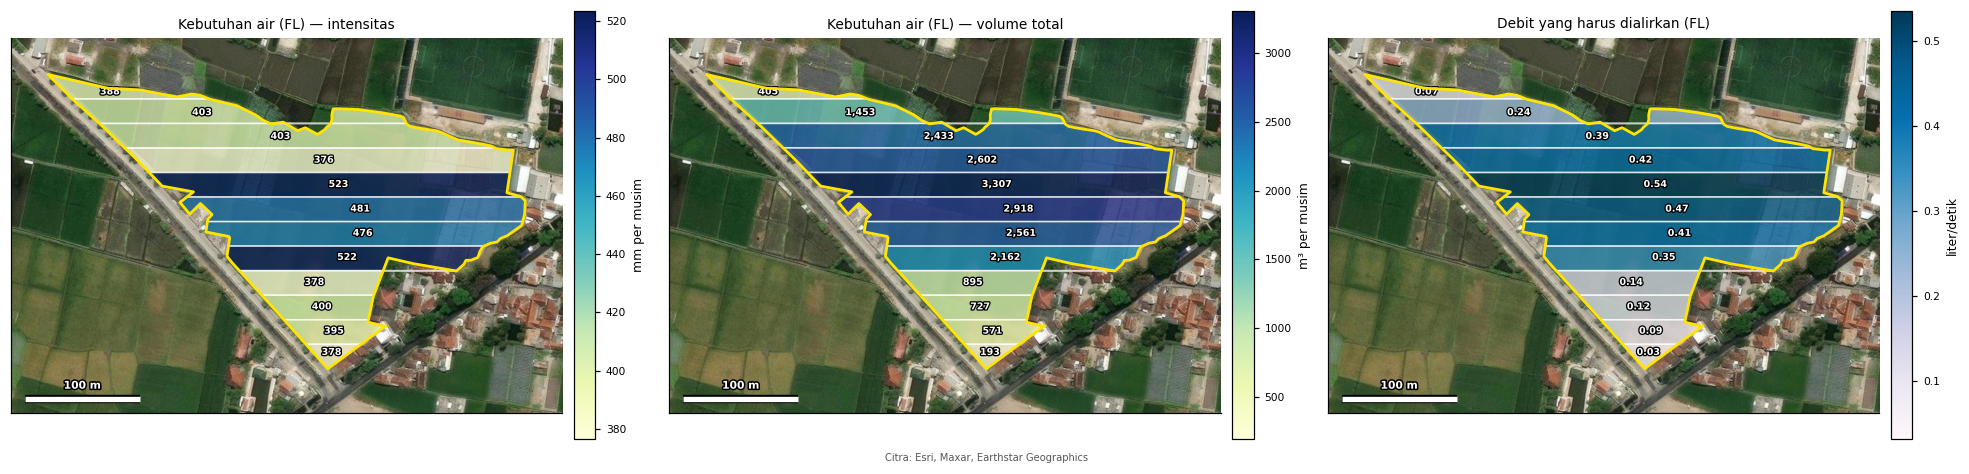

Kebutuhan air FL : 376 - 523 mm | 193 - 3,307 m³
Debit per petak  : 0.03 - 0.54 l/detik  (total 3.27 l/detik)


In [76]:
fl  = ringkasan[ringkasan.rezim == "FL" ].set_index("id_petak")
sri = ringkasan[ringkasan.rezim == "SRI"].set_index("id_petak")
kb  = keb[keb.rezim == "FL"].set_index("id_petak")

fig, axes = plt.subplots(1, 3, figsize=ukuran_peta(3, 18.0))
peta_petak(fl["irigasi_mm"], "Kebutuhan air (FL) — intensitas",
           "mm per musim", cmap="YlGnBu", fmt="{:.0f}", ax=axes[0])
peta_petak(fl["irigasi_m3"], "Kebutuhan air (FL) — volume total",
           "m³ per musim", cmap="YlGnBu", fmt="{:,.0f}", ax=axes[1])
peta_petak(kb["debit_l_detik"], "Debit yang harus dialirkan (FL)",
           "liter/detik", cmap="PuBu", fmt="{:.2f}", ax=axes[2])
fig.text(0.5, 0.005, KREDIT if BASEMAP is not None else "(tanpa citra satelit)",
         ha="center", fontsize=6.5, color="#555")
plt.tight_layout(rect=[0, 0.02, 1, 1]); plt.show()

print(f"Kebutuhan air FL : {fl['irigasi_mm'].min():.0f} - {fl['irigasi_mm'].max():.0f} mm "
      f"| {fl['irigasi_m3'].min():,.0f} - {fl['irigasi_m3'].max():,.0f} m³")
print(f"Debit per petak  : {kb['debit_l_detik'].min():.2f} - {kb['debit_l_detik'].max():.2f} l/detik"
      f"  (total {kb['debit_l_detik'].sum():.2f} l/detik)")

### 11c. Peta water loss

Tiga jalur air keluar, masing-masing dengan skala warnanya sendiri. Perhatikan:
**perkolasi** paling beragam antar petak (karena tanahnya beda-beda), sedangkan
**penguapan** hampir seragam (cuacanya sama untuk semua petak).

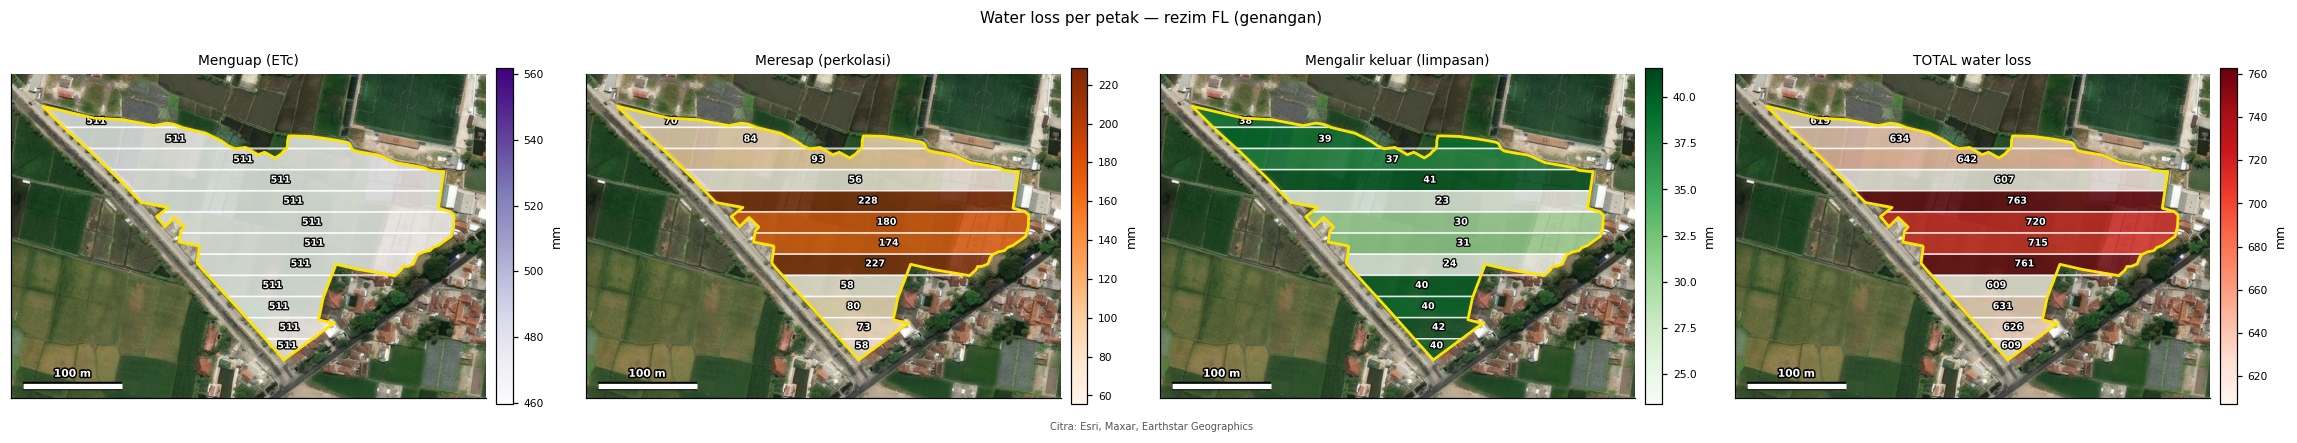

jalur                     terendah   tertinggi    rentang
---------------------------------------------------------
Menguap (ETc)              510.8 mm     510.8 mm      0.0 mm
Meresap                     55.7 mm     228.5 mm    172.8 mm
Mengalir keluar             23.4 mm      41.6 mm     18.2 mm
TOTAL                      607.3 mm     762.6 mm    155.3 mm


In [77]:
fl_total = fl["etc_mm"] + fl["perkolasi_mm"] + fl["limpasan_mm"]

fig, axes = plt.subplots(1, 4, figsize=ukuran_peta(4, 21.0))
peta_petak(fl["etc_mm"],       "Menguap (ETc)",            "mm", cmap="Purples", ax=axes[0])
peta_petak(fl["perkolasi_mm"], "Meresap (perkolasi)",      "mm", cmap="Oranges", ax=axes[1])
peta_petak(fl["limpasan_mm"],  "Mengalir keluar (limpasan)","mm", cmap="Greens",  ax=axes[2])
peta_petak(fl_total,           "TOTAL water loss",          "mm", cmap="Reds",    ax=axes[3])
fig.suptitle("Water loss per petak — rezim FL (genangan)", fontsize=10, y=1.00)
fig.text(0.5, 0.005, KREDIT if BASEMAP is not None else "(tanpa citra satelit)",
         ha="center", fontsize=6.5, color="#555")
plt.tight_layout(rect=[0, 0.02, 1, 0.97]); plt.show()

print(f"{'jalur':<22}{'terendah':>12}{'tertinggi':>12}{'rentang':>11}")
print("-" * 57)
for nama, sr in [("Menguap (ETc)", fl["etc_mm"]), ("Meresap", fl["perkolasi_mm"]),
                 ("Mengalir keluar", fl["limpasan_mm"]), ("TOTAL", fl_total)]:
    print(f"{nama:<22}{sr.min():>10.1f} mm{sr.max():>10.1f} mm{sr.max()-sr.min():>9.1f} mm")

### 11d. Perbandingan FL vs SRI di peta yang sama

Supaya adil, dua peta di bawah memakai **skala warna yang sama** (rentang gabungan),
jadi perbedaan warnanya benar-benar berarti — bukan sekadar efek penskalaan otomatis.

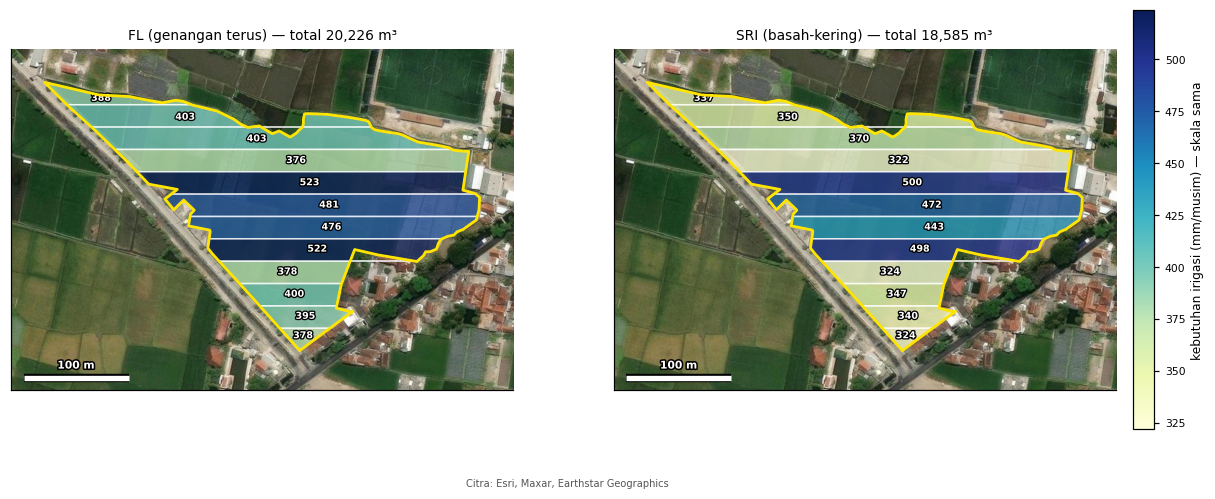

Selisih FL - SRI : 1,641 m³ semusim (8.1%)


In [26]:
vmin = min(fl["irigasi_mm"].min(), sri["irigasi_mm"].min())
vmax = max(fl["irigasi_mm"].max(), sri["irigasi_mm"].max())
norm = plt.Normalize(vmin, vmax); cm = plt.get_cmap("YlGnBu")

fig, axes = plt.subplots(1, 2, figsize=ukuran_peta(2, 13.5, porsi_peta=0.88))
for ax, (nama, data) in zip(axes, [("FL (genangan terus)", fl), ("SRI (basah-kering)", sri)]):
    if BASEMAP is not None:
        ax.imshow(BASEMAP, extent=EXTENT, origin="upper", interpolation="bilinear", zorder=0)
    for poly, (_, r) in zip(petak_poly, petak.iterrows()):
        val = float(data.loc[r["id_petak"], "irigasi_mm"])
        ax.add_patch(MplPolygon(poly, closed=True, facecolor=cm(norm(val)),
                                edgecolor="white", linewidth=1.0, alpha=0.75, zorder=2))
        cx, cy = pusat_poligon(poly)
        ax.text(cx, cy, f"{val:.0f}", ha="center", va="center", fontsize=6.2, zorder=4,
                color="white", weight="bold",
                path_effects=[pe.withStroke(linewidth=1.7, foreground="black")])
    ax.plot(np.append(X, X[0]), np.append(Y, Y[0]), color="#ffe400", lw=1.8, zorder=5)
    batang_skala(ax)
    ax.set_xlim(X.min()-32, X.max()+32); ax.set_ylim(Y.min()-38, Y.max()+32)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title(f"{nama} — total {data['irigasi_m3'].sum():,.0f} m³", fontsize=9)

sm = plt.cm.ScalarMappable(norm=norm, cmap=cm); sm.set_array([])
cb = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.015)
cb.set_label("kebutuhan irigasi (mm/musim) — skala sama", fontsize=8)
cb.ax.tick_params(labelsize=7)
fig.text(0.5, 0.005, KREDIT if BASEMAP is not None else "(tanpa citra satelit)",
         ha="center", fontsize=6.5, color="#555")
plt.show()

hemat = fl["irigasi_m3"].sum() - sri["irigasi_m3"].sum()
print(f"Selisih FL - SRI : {hemat:,.0f} m³ semusim "
      f"({100*hemat/fl['irigasi_m3'].sum():.1f}%)")

### 11e. Ekspor KML berwarna — buka lagi di Google Earth

Peta di atas bagus untuk laporan, tapi untuk kerja lapangan lebih enak dibuka langsung
di Google Earth di atas citra aslinya. Sel ini menulis KML dengan petak yang **sudah
diwarnai menurut kebutuhan air**, lengkap dengan balon informasi tiap petak.

Catatan teknis: KML memakai urutan warna `aabbggrr` (alfa-biru-hijau-merah) —
**terbalik** dari `rrggbb` yang biasa dipakai di web.

In [27]:
def warna_kml(rgba, alfa=0.62):
    '''(r,g,b,a) matplotlib -> string warna KML 'aabbggrr'.'''
    r, g, b = (int(round(255*c)) for c in rgba[:3])
    return f"{int(round(255*alfa)):02x}{b:02x}{g:02x}{r:02x}"

def tulis_kml(berkas, nilai, judul, satuan, cmap="YlOrRd"):
    v    = {r["id_petak"]: float(nilai[r["id_petak"]]) for _, r in petak.iterrows()}
    norm = plt.Normalize(min(v.values()), max(v.values()))
    cm   = plt.get_cmap(cmap)

    gaya, tempat = [], []
    for poly, (_, r) in zip(petak_poly, petak.iterrows()):
        pid  = r["id_petak"]; val = v[pid]
        gaya.append(f'''    <Style id="s_{pid}">
      <LineStyle><color>ffffffff</color><width>1.6</width></LineStyle>
      <PolyStyle><color>{warna_kml(cm(norm(val)))}</color></PolyStyle>
    </Style>''')

        # tutup cincin: titik pertama diulang di akhir (syarat KML)
        titik = [(px/M_PER_DEG_LON + lon0, py/M_PER_DEG_LAT + lat0) for px, py in poly]
        titik.append(titik[0])
        koord = " ".join(f"{lo:.8f},{la:.8f},0" for lo, la in titik)

        f_ = fl.loc[pid]; s_ = sri.loc[pid]; k_ = kb.loc[pid]
        info = (f"<![CDATA["
                f"<b>{judul}: {val:,.1f} {satuan}</b><br/><hr/>"
                f"Luas: {r['luas_m2']:,.0f} m² = {r['luas_ha']:.4f} ha<br/>"
                f"Cara ambil air: {r['cara_ambil_air']}<br/>"
                f"Koef. perkolasi: {r['a_perkolasi']:.2e} /detik<br/><hr/>"
                f"<b>Kebutuhan air</b><br/>"
                f"&nbsp;FL : {f_['irigasi_mm']:,.0f} mm = {f_['irigasi_m3']:,.0f} m³<br/>"
                f"&nbsp;SRI: {s_['irigasi_mm']:,.0f} mm = {s_['irigasi_m3']:,.0f} m³<br/>"
                f"&nbsp;Debit: {k_['debit_l_detik']:.2f} l/detik<br/><hr/>"
                f"<b>Water loss (FL)</b><br/>"
                f"&nbsp;Menguap : {f_['etc_mm']:,.0f} mm<br/>"
                f"&nbsp;Meresap : {f_['perkolasi_mm']:,.0f} mm<br/>"
                f"&nbsp;Mengalir: {f_['limpasan_mm']:,.0f} mm"
                f"]]>")
        tempat.append(f'''    <Placemark>
      <name>{pid}</name>
      <description>{info}</description>
      <styleUrl>#s_{pid}</styleUrl>
      <Polygon><outerBoundaryIs><LinearRing>
        <coordinates>{koord}</coordinates>
      </LinearRing></outerBoundaryIs></Polygon>
    </Placemark>''')

    isi = ('<?xml version="1.0" encoding="UTF-8"?>\n'
           '<kml xmlns="http://www.opengis.net/kml/2.2">\n  <Document>\n'
           f'    <name>{judul} — {LUAS_HA:.3f} ha</name>\n'
           + "\n".join(gaya) + "\n" + "\n".join(tempat)
           + "\n  </Document>\n</kml>\n")
    berkas.write_text(isi, encoding="utf-8")
    return berkas

for nama, nilai, judul, satuan, cmap in [
    ("petak_kebutuhan_air.kml", fl["irigasi_mm"],   "Kebutuhan air (FL)", "mm/musim", "YlGnBu"),
    ("petak_water_loss.kml",    fl_total,           "Total water loss",   "mm/musim", "Reds"),
    ("petak_perkolasi.kml",     fl["perkolasi_mm"], "Perkolasi",          "mm/musim", "Oranges"),
]:
    f = tulis_kml(OUT_DIR / nama, nilai, judul, satuan, cmap)
    print(f"  {nama:<28} {f.stat().st_size:>7,} byte")

print(f"\nBuka berkas di atas dengan Google Earth -> petak muncul berwarna")
print(f"di atas citra asli, klik petaknya untuk lihat angka lengkapnya.")

  petak_kebutuhan_air.kml       14,183 byte
  petak_water_loss.kml          14,157 byte
  petak_perkolasi.kml           14,058 byte

Buka berkas di atas dengan Google Earth -> petak muncul berwarna
di atas citra asli, klik petaknya untuk lihat angka lengkapnya.


### 11f. Water loss dalam persen

Peta di 11c memakai satuan **mm**. Di sini yang sama ditampilkan sebagai **persen
terhadap total air yang keluar** — jadi ketiga peta selalu berjumlah 100% di tiap petak.

Kenapa persen lebih berguna di sini? Karena **mm menjawab "berapa banyak"**, sedangkan
**persen menjawab "ke mana perginya"**. Untuk mencari petak yang bermasalah, persen lebih
cepat kelihatan: petak dengan porsi *meresap* tinggi berarti tanahnya bocor, bukan
sekadar petaknya besar.

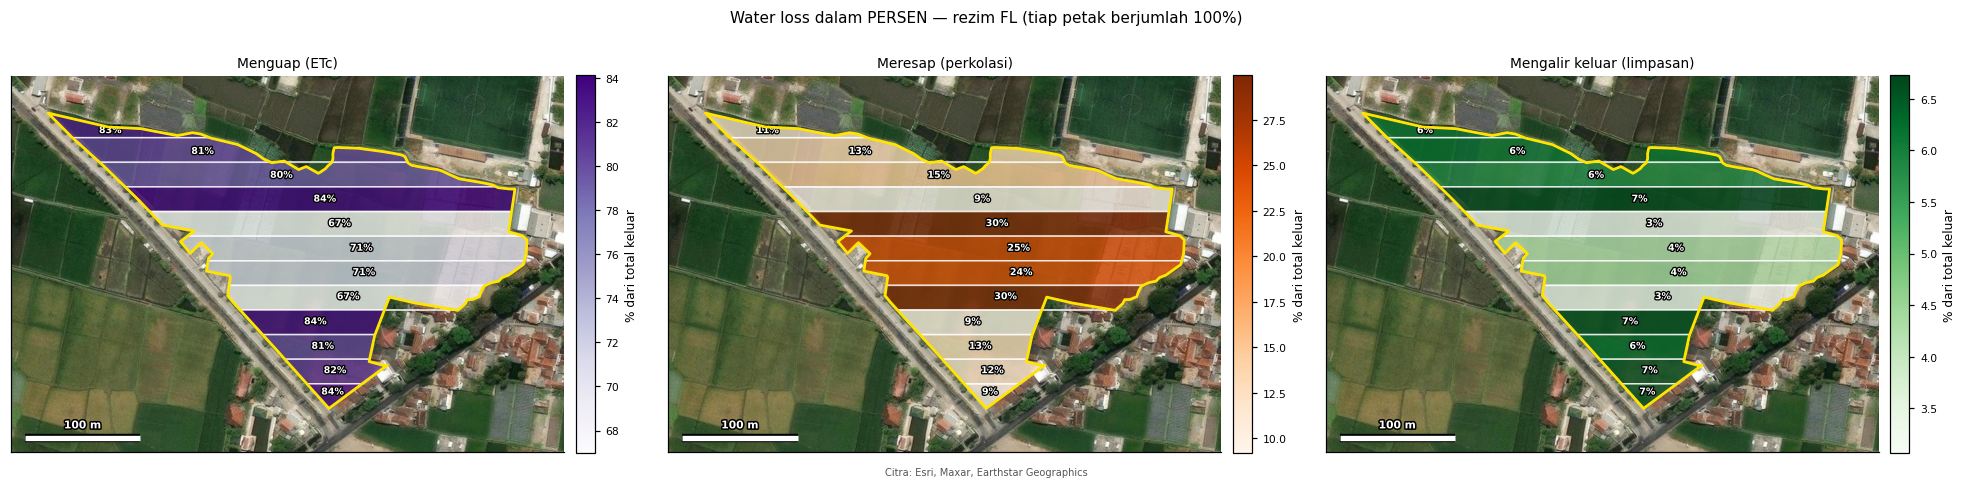

               menguap     meresap      keluar    jumlah
--------------------------------------------------------
P01              82.5%       11.4%        6.1%    100.0%
P02              80.6%       13.2%        6.2%    100.0%
P03              79.6%       14.6%        5.8%    100.0%
P04              84.1%        9.2%        6.7%    100.0%
P05              67.0%       30.0%        3.1%    100.0%
P06              70.9%       25.0%        4.1%    100.0%
P07              71.4%       24.3%        4.3%    100.0%
P08              67.1%       29.8%        3.1%    100.0%
P09              83.9%        9.5%        6.6%    100.0%
P10              80.9%       12.7%        6.4%    100.0%
P11              81.6%       11.7%        6.6%    100.0%
P12              83.9%        9.5%        6.6%    100.0%


In [28]:
wlf = wl[wl.rezim == "FL" ].set_index("id_petak")
wls = wl[wl.rezim == "SRI"].set_index("id_petak")

fig, axes = plt.subplots(1, 3, figsize=ukuran_peta(3, 18.0))
peta_petak(wlf["etc_pct"],       "Menguap (ETc)",             "% dari total keluar",
           cmap="Purples", fmt="{:.0f}%", ax=axes[0])
peta_petak(wlf["perkolasi_pct"], "Meresap (perkolasi)",       "% dari total keluar",
           cmap="Oranges", fmt="{:.0f}%", ax=axes[1])
peta_petak(wlf["limpasan_pct"],  "Mengalir keluar (limpasan)", "% dari total keluar",
           cmap="Greens",  fmt="{:.0f}%", ax=axes[2])
fig.suptitle("Water loss dalam PERSEN — rezim FL (tiap petak berjumlah 100%)",
             fontsize=10, y=1.00)
fig.text(0.5, 0.005, KREDIT if BASEMAP is not None else "(tanpa citra satelit)",
         ha="center", fontsize=6.5, color="#555")
plt.tight_layout(rect=[0, 0.02, 1, 0.96]); plt.show()

print(f"{'':<10}{'menguap':>12}{'meresap':>12}{'keluar':>12}{'jumlah':>10}")
print("-" * 56)
for pid in petak["id_petak"]:
    r = wlf.loc[pid]
    print(f"{pid:<10}{r['etc_pct']:>11.1f}%{r['perkolasi_pct']:>11.1f}%"
          f"{r['limpasan_pct']:>11.1f}%{r['etc_pct']+r['perkolasi_pct']+r['limpasan_pct']:>9.1f}%")

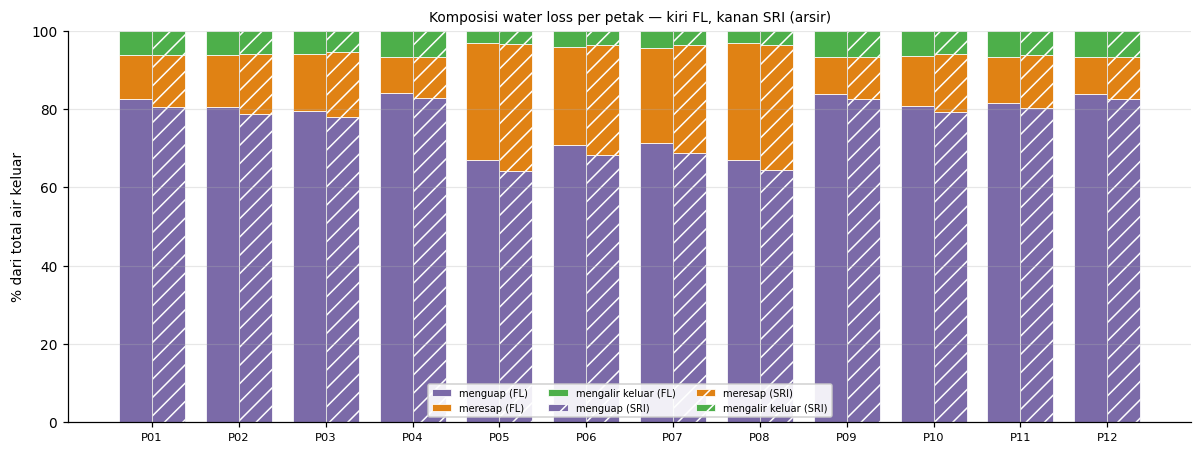

Porsi MENGUAP hampir seragam -> cuacanya sama untuk semua petak.
Porsi MERESAP paling beragam -> inilah yang membedakan petak, karena tanahnya beda.
  meresap FL : 9.2% - 30.0%
  meresap SRI: 10.4% - 32.3%


In [29]:
# Batang bertumpuk 100% - komposisi water loss tiap petak, FL vs SRI
fig, ax = plt.subplots(figsize=(11, 4.2))
xs, lebar = np.arange(len(petak)), 0.38
for j, (rezim, data, hatch) in enumerate([("FL", wlf, ""), ("SRI", wls, "//")]):
    d = data.loc[petak["id_petak"]]
    bawah = np.zeros(len(d))
    for k, w, nm in [("etc_pct", "#7b6aa8", "menguap"),
                     ("perkolasi_pct", "#e08214", "meresap"),
                     ("limpasan_pct", "#4daf4a", "mengalir keluar")]:
        ax.bar(xs + (j-0.5)*lebar, d[k], lebar, bottom=bawah, color=w, hatch=hatch,
               edgecolor="white", linewidth=0.5,
               label=f"{nm} ({rezim})")
        bawah += d[k].to_numpy()
ax.set_xticks(xs); ax.set_xticklabels(petak["id_petak"], fontsize=7.5)
ax.set_ylim(0, 100); ax.set_ylabel("% dari total air keluar")
ax.set_title("Komposisi water loss per petak — kiri FL, kanan SRI (arsir)", fontsize=9)
ax.legend(fontsize=6.5, ncol=3, loc="lower center", framealpha=0.9)
plt.tight_layout(); plt.show()

print("Porsi MENGUAP hampir seragam -> cuacanya sama untuk semua petak.")
print("Porsi MERESAP paling beragam -> inilah yang membedakan petak, karena tanahnya beda.")
print(f"  meresap FL : {wlf['perkolasi_pct'].min():.1f}% - {wlf['perkolasi_pct'].max():.1f}%")
print(f"  meresap SRI: {wls['perkolasi_pct'].min():.1f}% - {wls['perkolasi_pct'].max():.1f}%")

### 11g. Irigasi pertama untuk menggenang

Ada satu hal yang **belum dihitung** di seluruh notebook sampai titik ini: air untuk
**menggenangi sawah pertama kali**.

Di simulasi, tiap petak dimulai dengan `h_awal = 20 mm` — seolah-olah sudah tergenang
gratis. Padahal untuk sampai ke kondisi itu butuh air, dan jumlahnya tidak sedikit.

Tiga komponennya:

| Komponen | Rumus | Keterangan |
|---|---|---|
| **Penjenuhan tanah** | `(θ_jenuh − θ_awal) × zona akar` | mengisi pori tanah sampai jenuh |
| **Lapisan genangan** | `tinggi target` | air yang benar-benar tergenang di atas tanah |
| **Kehilangan saat mengisi** | `(perkolasi + evaporasi) × lama isi` | bocor sambil diisi |

Zona akar 300 mm diambil dari Arif (`Zr`). Kadar air jenuh dan awal adalah perkiraan —
untuk tanah sawah lempung, θ_jenuh sekitar 0,45–0,55.

In [30]:
ZONA_AKAR_MM = 300.0     # kedalaman zona akar (Arif: Zr ~ 300 mm)
THETA_JENUH  = 0.50      # kadar air saat jenuh (m3/m3)
THETA_AWAL   = 0.30      # kadar air sebelum diairi (tanah lembap, belum jenuh)
LAMA_ISI_JAM = 6.0       # target lama pengisian satu petak

PENJENUHAN_MM = (THETA_JENUH - THETA_AWAL) * ZONA_AKAR_MM
eto_isi = float(cuaca["eto_mm"][:10].mean())

baris_isi = []
for _, p in petak.iterrows():
    for rezim in ("FL", "SRI"):
        target = ATURAN_TMA[rezim]["awal"][0]                 # tinggi genangan target
        perk   = p["perk_per_mm"] * max(target, 1.0)          # perkolasi saat tergenang
        rugi   = (perk + 1.1*eto_isi) * (LAMA_ISI_JAM/24.0)   # kehilangan selama mengisi
        total  = PENJENUHAN_MM + target + rugi
        baris_isi.append({
            "id_petak": p["id_petak"], "rezim": rezim,
            "luas_ha": p["luas_ha"], "luas_m2": p["luas_m2"],
            "penjenuhan_mm": PENJENUHAN_MM, "genangan_mm": target,
            "rugi_isi_mm": rugi, "total_mm": total,
            "total_m3": total * p["luas_m2"] / 1000.0,
        })
isi = pd.DataFrame(baris_isi)
isi_fl = isi[isi.rezim == "FL"].set_index("id_petak")

print(f"Penjenuhan tanah : ({THETA_JENUH} - {THETA_AWAL}) x {ZONA_AKAR_MM:.0f} mm "
      f"= {PENJENUHAN_MM:.0f} mm  (sama untuk semua petak)")
print(f"ETo saat mengisi : {eto_isi:.2f} mm/hari, lama isi {LAMA_ISI_JAM:.0f} jam\n")
print(isi_fl[["luas_ha", "penjenuhan_mm", "genangan_mm", "rugi_isi_mm",
              "total_mm", "total_m3"]].to_string(float_format=lambda v: f"{v:,.1f}"))

tot_fl  = isi[isi.rezim=="FL" ]["total_m3"].sum()
tot_sri = isi[isi.rezim=="SRI"]["total_m3"].sum()
irig_fl = ringkasan[ringkasan.rezim=="FL"]["irigasi_m3"].sum()
print(f"\n{'='*64}")
print(f"  Air untuk menggenangi SELURUH lahan pertama kali")
print(f"    FL  : {tot_fl:8,.0f} m3  ({tot_fl/(LUAS_M2/1000):.0f} mm)")
print(f"    SRI : {tot_sri:8,.0f} m3  ({tot_sri/(LUAS_M2/1000):.0f} mm)")
print(f"    Sebagai porsi irigasi semusim (FL): {100*tot_fl/irig_fl:.1f}%")
print(f"{'='*64}")
print("Ini kebutuhan SEKALI di awal, tapi harus tersedia SERENTAK -")
print("dan itulah yang menentukan ukuran saluran, bukan rata-rata semusim.")

Penjenuhan tanah : (0.5 - 0.3) x 300 mm = 60 mm  (sama untuk semua petak)
ETo saat mengisi : 3.11 mm/hari, lama isi 6 jam

          luas_ha  penjenuhan_mm  genangan_mm  rugi_isi_mm  total_mm  total_m3
id_petak                                                                      
P01           0.1           60.0           20          1.1      81.1      84.5
P02           0.4           60.0           20          1.1      81.1     292.4
P03           0.6           60.0           20          1.1      81.1     489.3
P04           0.7           60.0           20          1.0      81.0     559.9
P05           0.6           60.0           20          1.5      81.5     515.1
P06           0.6           60.0           20          1.4      81.4     493.5
P07           0.5           60.0           20          1.4      81.4     437.4
P08           0.4           60.0           20          1.5      81.5     337.5
P09           0.2           60.0           20          1.0      81.0     191.9
P10     

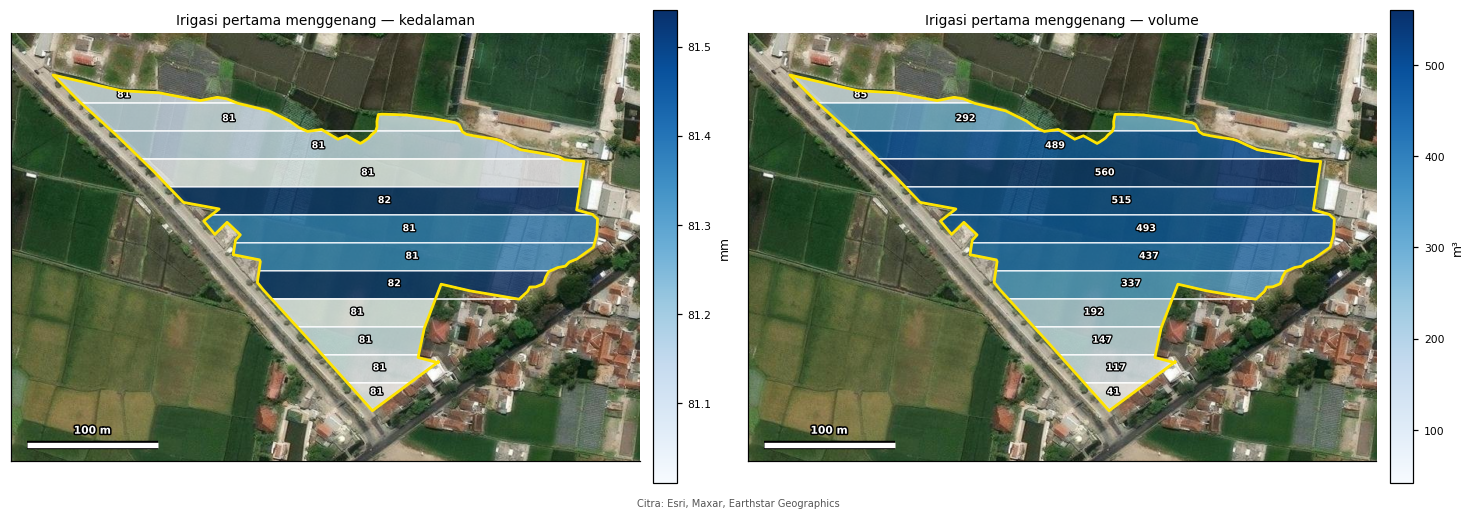

In [31]:
fig, axes = plt.subplots(1, 2, figsize=ukuran_peta(2, 13.5))
peta_petak(isi_fl["total_mm"], "Irigasi pertama menggenang — kedalaman",
           "mm", cmap="Blues", fmt="{:.0f}", ax=axes[0])
peta_petak(isi_fl["total_m3"], "Irigasi pertama menggenang — volume",
           "m³", cmap="Blues", fmt="{:,.0f}", ax=axes[1])
fig.text(0.5, 0.005, KREDIT if BASEMAP is not None else "(tanpa citra satelit)",
         ha="center", fontsize=6.5, color="#555")
plt.tight_layout(rect=[0, 0.02, 1, 1]); plt.show()

### 11h. Debit saat menggenang

Sekarang pertanyaan yang paling praktis: **kalau petak mau diisi dalam sekian jam,
berapa debit yang harus masuk lewat pintunya?**

$$ Q = \frac{\text{volume pengisian}}{\text{lama pengisian}} $$

Lalu dari debit itu bisa dihitung **diameter pintu/pipa** yang dibutuhkan, memakai
persamaan orifice Li et al. (2024) pers. (4):

$$ Q = C_d \cdot a \cdot \sqrt{2g\,H} \quad\Longrightarrow\quad d = \sqrt{\frac{4}{\pi}\cdot\frac{Q}{C_d\sqrt{2gH}}} $$

dengan `H` = tinggi tekan di atas lubang. Li memakai `H = 0,010 m` karena petani menahan
air dengan balok di hilir pintu supaya lubangnya tetap terendam.

**Perhatikan bedanya dengan debit rata-rata semusim.** Debit rata-rata itu angka
perencanaan jangka panjang; debit pengisian ini angka *sesaat* yang menentukan ukuran fisik pintu.

In [32]:
def diameter_orifice(Q_m3s, tinggi_tekan_m=0.010, Cd=0.62):
    '''Diameter lubang pengambilan (m) untuk debit Q - Li pers. (4) dibalik.'''
    if Q_m3s <= 0:
        return 0.0
    kecepatan = Cd * math.sqrt(2*9.81*tinggi_tekan_m)
    return math.sqrt(4.0*(Q_m3s/kecepatan)/math.pi)

# --- debit pengisian per petak, untuk beberapa target lama pengisian ---
JAM_UJI = (3, 6, 12, 24)
baris_q = []
for _, r in isi_fl.reset_index().iterrows():
    for jam in JAM_UJI:
        Q = r["total_m3"] / (jam*3600.0)                 # m3/detik
        baris_q.append({"id_petak": r["id_petak"], "luas_ha": r["luas_ha"],
                        "lama_jam": jam, "volume_m3": r["total_m3"],
                        "Q_m3_detik": Q, "Q_l_detik": Q*1000,
                        "Q_l_detik_ha": Q*1000/r["luas_ha"],
                        "diameter_cm": diameter_orifice(Q)*100})
qisi = pd.DataFrame(baris_q)

print("DEBIT PENGISIAN SELURUH LAHAN menurut target lama pengisian")
print("=" * 72)
print(f"{'lama isi':>10}{'debit total':>16}{'per hektar':>16}{'vs rata2 semusim':>20}")
print("-" * 72)
dr_musim = ke_l_detik_ha(ringkasan[ringkasan.rezim=="FL"]["irigasi_m3"].sum()
                         / (LUAS_M2/1000) / N_HARI)
for jam in JAM_UJI:
    g = qisi[qisi.lama_jam == jam]
    tot_l = g["Q_l_detik"].sum()
    print(f"{jam:>8} jam{tot_l:>13,.1f} l/dt{tot_l/LUAS_HA:>12,.1f} l/dt/ha"
          f"{tot_l/LUAS_HA/dr_musim:>17,.0f}x")
print("-" * 72)
print(f"{'rata2 semusim':>10}{dr_musim*LUAS_HA:>13,.2f} l/dt{dr_musim:>12,.2f} l/dt/ha{1:>17}x")

DEBIT PENGISIAN SELURUH LAHAN menurut target lama pengisian
  lama isi     debit total      per hektar    vs rata2 semusim
------------------------------------------------------------------------
       3 jam        343.3 l/dt        75.2 l/dt/ha              105x
       6 jam        171.6 l/dt        37.6 l/dt/ha               52x
      12 jam         85.8 l/dt        18.8 l/dt/ha               26x
      24 jam         42.9 l/dt         9.4 l/dt/ha               13x
------------------------------------------------------------------------
rata2 semusim         3.27 l/dt        0.72 l/dt/ha                1x


In [33]:
print("DIAMETER PINTU/PIPA YANG DIBUTUHKAN PER PETAK")
print(f"(tinggi tekan H = 0,010 m seperti asumsi Li; Cd = 0,62)")
print("=" * 74)
pv = qisi.pivot(index="id_petak", columns="lama_jam", values="diameter_cm")
pv.columns = [f"{c} jam" for c in pv.columns]
pv.insert(0, "luas_ha", isi_fl["luas_ha"])
pv.insert(1, "volume_m3", isi_fl["total_m3"])
print(pv.to_string(float_format=lambda v: f"{v:,.1f}"))

d6 = qisi[qisi.lama_jam == 6]["diameter_cm"]
print(f"\nUntuk pengisian 6 jam, diameter pintu perlu {d6.min():.0f} - {d6.max():.0f} cm.")
print(f"Pintu di lokasi Li cuma 10 cm -> hanya cukup untuk petak terkecil.")
print()
print("ARTINYA: mengisi semua petak serentak itu tidak mungkin.")
print("Pengisian HARUS bergiliran - dan itu bukan kebiasaan lama yang bisa")
print("dihapus, melainkan keharusan hidraulik. WMS-nya perlu penjadwal giliran,")
print("bukan sekadar buka semua pintu bersamaan.")

# berapa petak yang bisa diisi serentak dengan kapasitas terbatas?
KAPASITAS_L_DETIK = 50.0
g6 = qisi[qisi.lama_jam == 6].sort_values("Q_l_detik")
kum, n_muat = 0.0, 0
for q in g6["Q_l_detik"]:
    if kum + q > KAPASITAS_L_DETIK: break
    kum += q; n_muat += 1
print(f"\nContoh: kalau saluran hanya sanggup {KAPASITAS_L_DETIK:.0f} l/detik, dalam satu")
print(f"giliran 6 jam cuma {n_muat} dari {len(petak)} petak yang bisa diisi "
      f"({kum:.1f} l/detik terpakai).")
print(f"Mengisi semua {len(petak)} petak perlu "
      f"{math.ceil(g6['Q_l_detik'].sum()/KAPASITAS_L_DETIK)} giliran "
      f"= {math.ceil(g6['Q_l_detik'].sum()/KAPASITAS_L_DETIK)*6} jam.")

DIAMETER PINTU/PIPA YANG DIBUTUHKAN PER PETAK
(tinggi tekan H = 0,010 m seperti asumsi Li; Cd = 0,62)
          luas_ha  volume_m3  3 jam  6 jam  12 jam  24 jam
id_petak                                                  
P01           0.1       84.5   19.0   13.5     9.5     6.7
P02           0.4      292.4   35.4   25.1    17.7    12.5
P03           0.6      489.3   45.8   32.4    22.9    16.2
P04           0.7      559.9   49.0   34.7    24.5    17.3
P05           0.6      515.1   47.0   33.3    23.5    16.6
P06           0.6      493.5   46.0   32.5    23.0    16.3
P07           0.5      437.4   43.3   30.6    21.7    15.3
P08           0.4      337.5   38.1   26.9    19.0    13.5
P09           0.2      191.9   28.7   20.3    14.4    10.1
P10           0.2      147.3   25.1   17.8    12.6     8.9
P11           0.1      117.2   22.4   15.9    11.2     7.9
P12           0.1       41.3   13.3    9.4     6.7     4.7

Untuk pengisian 6 jam, diameter pintu perlu 9 - 35 cm.
Pintu di lokasi 

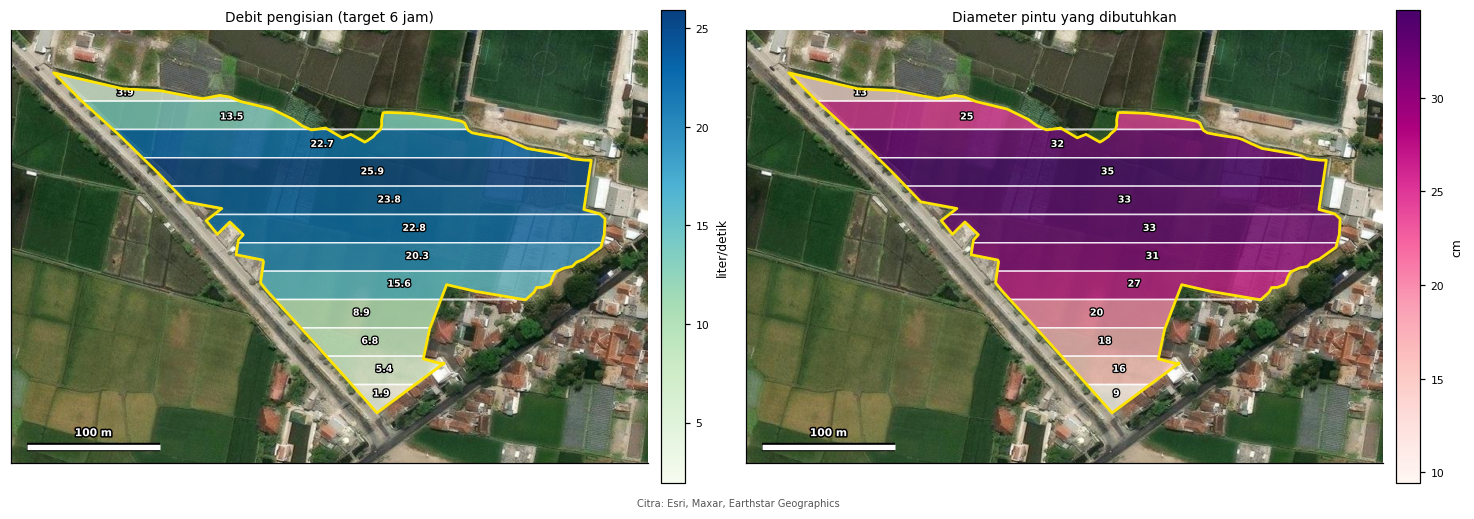

In [34]:
q6 = qisi[qisi.lama_jam == 6].set_index("id_petak")
fig, axes = plt.subplots(1, 2, figsize=ukuran_peta(2, 13.5))
peta_petak(q6["Q_l_detik"],   "Debit pengisian (target 6 jam)",
           "liter/detik", cmap="GnBu", fmt="{:.1f}", ax=axes[0])
peta_petak(q6["diameter_cm"], "Diameter pintu yang dibutuhkan",
           "cm", cmap="RdPu", fmt="{:.0f}", ax=axes[1])
fig.text(0.5, 0.005, KREDIT if BASEMAP is not None else "(tanpa citra satelit)",
         ha="center", fontsize=6.5, color="#555")
plt.tight_layout(rect=[0, 0.02, 1, 1]); plt.show()

### 11i. Tinggi air di sawah (TMA)

TMA berubah tiap hari, jadi satu peta saja tidak cukup. Tiga peta di bawah menampilkan
sisi yang berbeda:

| Peta | Menjawab |
|---|---|
| **TMA rata-rata** | Sepanjang musim, petak ini umumnya sebasah apa? |
| **TMA terendah** | Seberapa parah kekeringan terburuknya? |
| **Hari TMA < 0** | Berapa lama petak ini tidak tergenang? |

Acuan yang perlu diingat: **0 mm = permukaan tanah**, angka minus berarti air sudah
di bawah permukaan. Batas atas fisik ≈ **170 mm** (tinggi pematang, Chen `PZ1` = 168 mm).

In [35]:
tma = (harian.groupby(["id_petak", "rezim"])
       .agg(tma_rata=("tma", "mean"), tma_min=("tma", "min"), tma_maks=("tma", "max"))
       .reset_index())
tma["hari_kering"] = (harian[harian.tma < 0].groupby(["id_petak", "rezim"]).size()
                      .reindex(pd.MultiIndex.from_frame(tma[["id_petak","rezim"]]))
                      .fillna(0).astype(int).to_numpy())
tma_fl  = tma[tma.rezim == "FL" ].set_index("id_petak")
tma_sri = tma[tma.rezim == "SRI"].set_index("id_petak")

print("TINGGI MUKA AIR (mm, relatif permukaan tanah)")
print("=" * 76)
print(f"{'':<10}{'--------- FL ---------':^32}{'--------- SRI --------':^32}")
print(f"{'petak':<10}{'rata':>8}{'min':>8}{'maks':>8}{'kering':>8}"
      f"{'rata':>8}{'min':>8}{'maks':>8}{'kering':>8}")
print("-" * 76)
for pid in petak["id_petak"]:
    f_, s_ = tma_fl.loc[pid], tma_sri.loc[pid]
    print(f"{pid:<10}{f_['tma_rata']:>8.1f}{f_['tma_min']:>8.1f}{f_['tma_maks']:>8.1f}"
          f"{f_['hari_kering']:>8.0f}"
          f"{s_['tma_rata']:>8.1f}{s_['tma_min']:>8.1f}{s_['tma_maks']:>8.1f}"
          f"{s_['hari_kering']:>8.0f}")
print("-" * 76)
print(f"{'RERATA':<10}{tma_fl['tma_rata'].mean():>8.1f}{tma_fl['tma_min'].mean():>8.1f}"
      f"{tma_fl['tma_maks'].mean():>8.1f}{tma_fl['hari_kering'].mean():>8.0f}"
      f"{tma_sri['tma_rata'].mean():>8.1f}{tma_sri['tma_min'].mean():>8.1f}"
      f"{tma_sri['tma_maks'].mean():>8.1f}{tma_sri['hari_kering'].mean():>8.0f}")

TINGGI MUKA AIR (mm, relatif permukaan tanah)
               --------- FL ---------          --------- SRI --------     
petak         rata     min    maks  kering    rata     min    maks  kering
----------------------------------------------------------------------------
P01           10.4    -5.6    50.0      12    -4.0   -35.0    40.0      71
P02           10.0    -5.7    50.0      11    -4.9   -36.1    40.0      72
P03            9.8    -4.3    50.0      12    -5.0   -34.0    40.0      70
P04           10.9    -5.5    50.0      12    -4.1   -33.9    40.0      72
P05            8.2    -4.1    50.0      10    -7.0   -34.1    40.0      77
P06            8.8    -4.9    50.0      11    -7.7   -36.1    40.0      80
P07            8.9    -4.9    50.0      11    -6.9   -37.4    40.0      76
P08            8.2    -4.1    50.0      10    -6.9   -34.0    40.0      77
P09           10.8    -5.5    50.0      12    -4.3   -34.0    40.0      72
P10           10.1    -5.7    50.0      11    -4.7  

**Sebelum melihat petanya, satu hal penting.** Sebaran TMA antar petak dalam satu rezim
itu **sangat sempit** — untuk FL cuma sekitar 2–3 mm. Kalau skala warnanya dibiarkan
meregang otomatis mengikuti data, beda 2 mm akan tampak dramatis padahal tidak berarti apa-apa
(sensor lapangan pun sulit membedakannya).

Sebabnya masuk akal: **TMA dikunci oleh aturan kontrol**, bukan oleh tanahnya. Begitu air
turun sampai ambang pemicu, langsung diisi ke target — apa pun jenis tanahnya. Jadi
perbedaan tanah **tidak muncul di TMA, melainkan pindah ke jumlah air yang dipakai**
(lihat 11b: irigasi 376–523 mm, sebaran jauh lebih lebar).

Karena itu peta di bawah memakai **skala warna dipatok** (−60 s/d +60 mm), sama untuk
kedua rezim. Petak-petak FL yang tampak seragam itu memang **benar-benar seragam**.

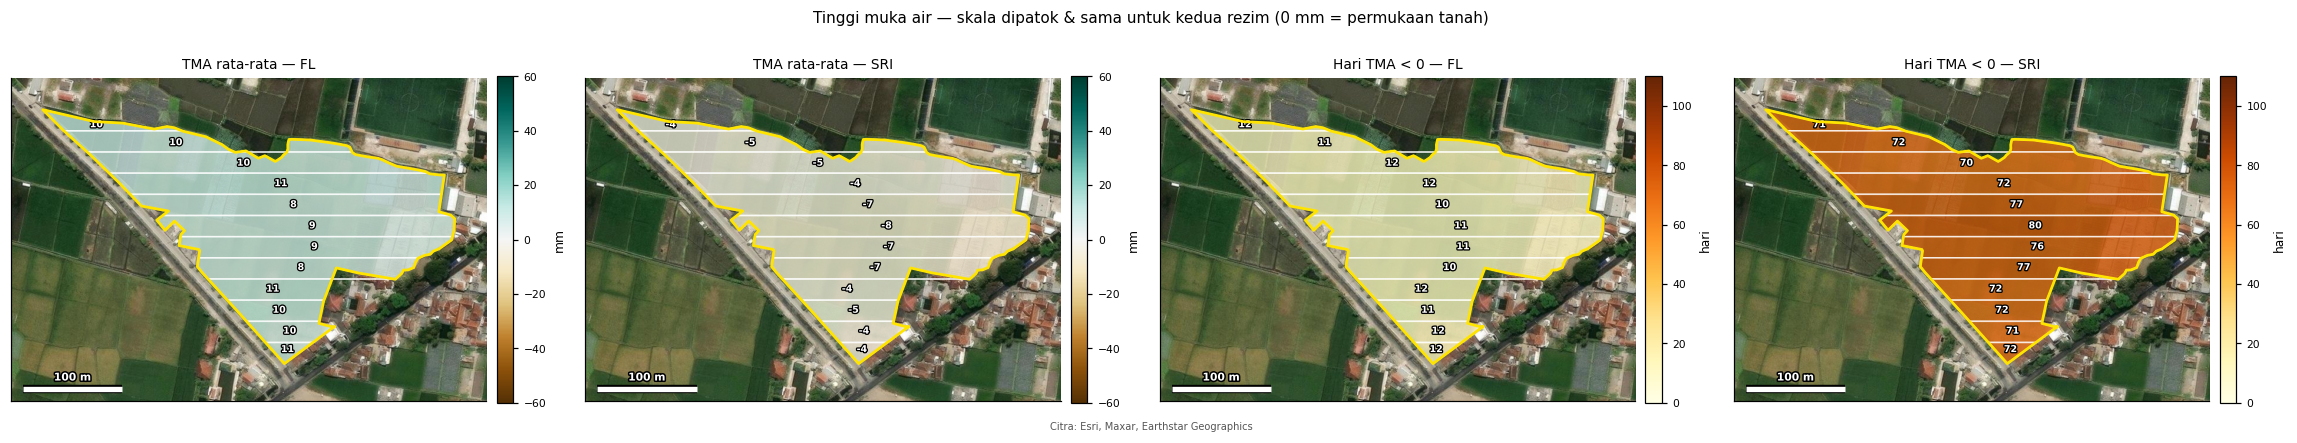

FL   TMA rata-rata :    8.2 ..   10.9 mm (sebaran hanya  2.7 mm)   hari kering 10-12
SRI  TMA rata-rata :   -7.7 ..   -4.0 mm (sebaran hanya  3.6 mm)   hari kering 70-80

Sebaran ANTAR REZIM jauh lebih besar daripada sebaran ANTAR PETAK.
Itu bukti bahwa yang menentukan TMA adalah cara mengoperasikan pintu air,
bukan sifat petaknya. Konsekuensi untuk WMS: TMA adalah variabel yang KAMU
kendalikan, sedangkan konsumsi air adalah AKIBAT yang kamu tanggung.


In [36]:
fig, axes = plt.subplots(1, 4, figsize=ukuran_peta(4, 21.0))
# Skala dipatok & simetris terhadap 0 supaya colormap divergen bermakna:
# coklat = di bawah permukaan (kering), biru-hijau = tergenang.
peta_petak(tma_fl["tma_rata"],  "TMA rata-rata — FL",  "mm", cmap="BrBG",
           fmt="{:.0f}", ax=axes[0], vmin=-60, vmax=60)
peta_petak(tma_sri["tma_rata"], "TMA rata-rata — SRI", "mm", cmap="BrBG",
           fmt="{:.0f}", ax=axes[1], vmin=-60, vmax=60)
peta_petak(tma_fl["hari_kering"],  "Hari TMA < 0 — FL",  "hari", cmap="YlOrBr",
           fmt="{:.0f}", ax=axes[2], vmin=0, vmax=N_HARI)
peta_petak(tma_sri["hari_kering"], "Hari TMA < 0 — SRI", "hari", cmap="YlOrBr",
           fmt="{:.0f}", ax=axes[3], vmin=0, vmax=N_HARI)
fig.suptitle("Tinggi muka air — skala dipatok & sama untuk kedua rezim "
             "(0 mm = permukaan tanah)", fontsize=10, y=1.00)
fig.text(0.5, 0.005, KREDIT if BASEMAP is not None else "(tanpa citra satelit)",
         ha="center", fontsize=6.5, color="#555")
plt.tight_layout(rect=[0, 0.02, 1, 0.96]); plt.show()

for nm, d in [("FL", tma_fl), ("SRI", tma_sri)]:
    r = d["tma_rata"]; k = d["hari_kering"]
    print(f"{nm:<4} TMA rata-rata : {r.min():6.1f} .. {r.max():6.1f} mm "
          f"(sebaran hanya {r.max()-r.min():4.1f} mm)   hari kering {k.min():.0f}-{k.max():.0f}")
print()
print("Sebaran ANTAR REZIM jauh lebih besar daripada sebaran ANTAR PETAK.")
print("Itu bukti bahwa yang menentukan TMA adalah cara mengoperasikan pintu air,")
print("bukan sifat petaknya. Konsekuensi untuk WMS: TMA adalah variabel yang KAMU")
print("kendalikan, sedangkan konsumsi air adalah AKIBAT yang kamu tanggung.")

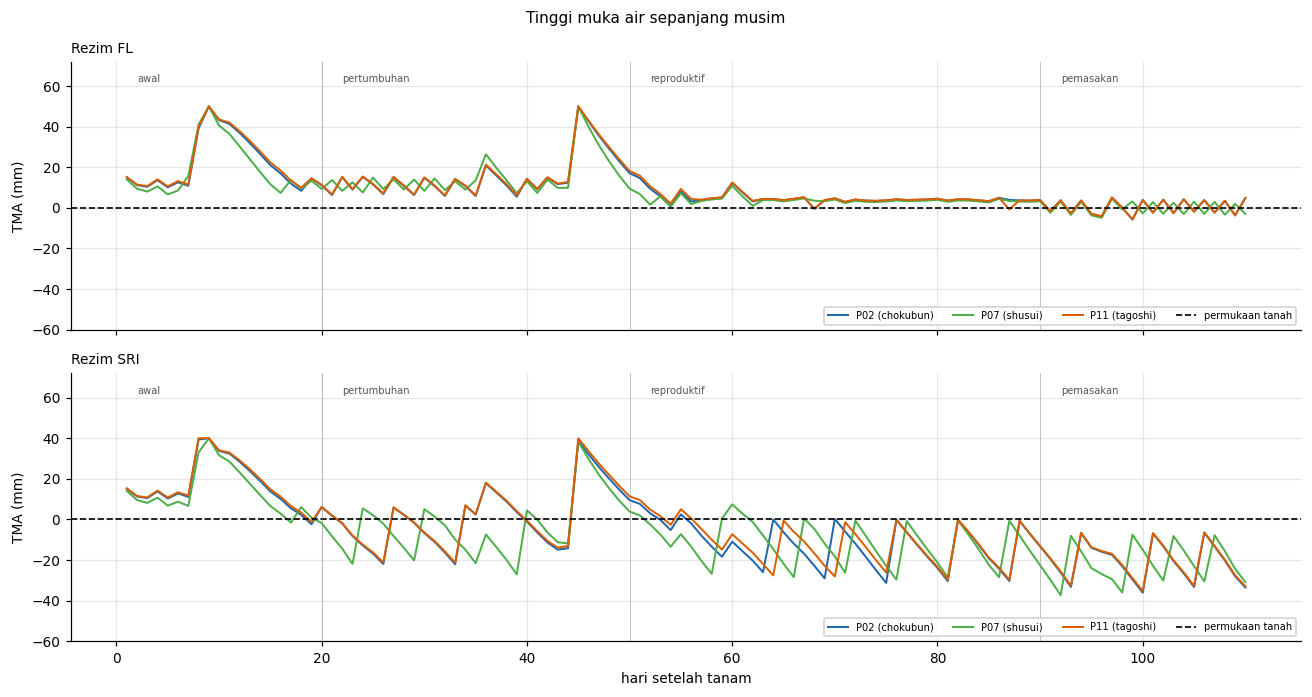

FL  : gerigi rapat & dangkal -> diairi sedikit-sedikit tapi sering.
SRI : gerigi lebar & dalam  -> dibiarkan turun jauh, lalu diisi banyak sekaligus.

TMA tertinggi sepanjang musim : 50 mm
Tinggi lubang buang (hd)      : 30 - 50 mm  <- INI yang membatasi, bukan pematang
Tinggi pematang (Chen, PZ1)   : 170 mm  (sengaja di luar skala grafik)

Air tidak pernah mendekati puncak pematang, karena sudah keluar lewat lubang
buang jauh sebelum itu. Pematang baru berperan kalau lubang buang tersumbat,
atau kalau hujannya jauh lebih ekstrem daripada yang disimulasikan di sini.


In [37]:
# Deret waktu TMA - tiga petak wakil, dua rezim
wakil = [petak["id_petak"].iloc[1], petak["id_petak"].iloc[len(petak)//2],
         petak["id_petak"].iloc[-2]]
fig, axes = plt.subplots(2, 1, figsize=(12, 6.4), sharex=True)
batas_fase = np.cumsum([d for _, d in FASE])[:-1]

for ax, rezim in zip(axes, ("FL", "SRI")):
    for pid, w in zip(wakil, ("#2166ac", "#4daf4a", "#d95f02")):
        g = harian[(harian.id_petak == pid) & (harian.rezim == rezim)]
        jt = petak.set_index("id_petak").loc[pid, "cara_ambil_air"]
        ax.plot(g["hari"], g["tma"], lw=1.3, color=w, label=f"{pid} ({jt})")
    ax.axhline(0, color="black", lw=1.1, ls="--", label="permukaan tanah")
    for b in batas_fase:
        ax.axvline(b, color="grey", lw=0.6, alpha=0.5)
    for (nm, _), x in zip(FASE, np.concatenate([[0], batas_fase])):
        ax.text(x + 2, 62, nm, fontsize=6.5, color="#555")
    # Skala dipersempit ke -60..72 mm supaya gerigi kendalinya terbaca.
    # Pematang (170 mm) sengaja DI LUAR skala - keterangannya di bawah gambar.
    ax.set_ylabel("TMA (mm)"); ax.set_ylim(-60, 72)
    ax.set_title(f"Rezim {rezim}", fontsize=9, loc="left")
    ax.legend(fontsize=6.5, ncol=4, loc="lower right", framealpha=0.9)
axes[1].set_xlabel("hari setelah tanam")
fig.suptitle("Tinggi muka air sepanjang musim", fontsize=10)
plt.tight_layout(); plt.show()

print("FL  : gerigi rapat & dangkal -> diairi sedikit-sedikit tapi sering.")
print("SRI : gerigi lebar & dalam  -> dibiarkan turun jauh, lalu diisi banyak sekaligus.")
tmaks = harian["tma"].max()
print(f"\nTMA tertinggi sepanjang musim : {tmaks:.0f} mm")
print( "Tinggi lubang buang (hd)      : 30 - 50 mm  <- INI yang membatasi, bukan pematang")
print( "Tinggi pematang (Chen, PZ1)   : 170 mm  (sengaja di luar skala grafik)")
print()
print("Air tidak pernah mendekati puncak pematang, karena sudah keluar lewat lubang")
print("buang jauh sebelum itu. Pematang baru berperan kalau lubang buang tersumbat,")
print("atau kalau hujannya jauh lebih ekstrem daripada yang disimulasikan di sini.")

---
## 12. Seberapa besar pengaruh aturan kontrol?

Ini pelajaran paling penting untuk WMS:

> **Kebutuhan air bukan sifat tetap sebuah lahan.**
> Angkanya berubah tergantung bagaimana pintu airnya dioperasikan.

Di bawah ini satu angka digeser saja — **ambang pemicu irigasi SRI**, dari dangkal (−10 mm)
ke dalam (−60 mm). Lahan sama, cuaca sama, tanaman sama. Lihat berapa jauh hasilnya bergeser.

In [38]:
import copy

petak_uji = petak.iloc[len(petak)//2]          # satu petak sebagai wakil
baris_uji = []

for pemicu in (-10, -20, -30, -40, -50, -60):
    aturan = copy.deepcopy(ATURAN_TMA)
    for fase in ("pertumbuhan", "reproduktif", "pemasakan"):
        t, _, hd = aturan["SRI"][fase]
        aturan["SRI"][fase] = (t, pemicu, hd)      # geser ambangnya saja
    sim = simulasi_petak(cuaca, "SRI", petak_uji["perk_per_mm"], aturan=aturan)
    diairi = sim["irigasi"][sim["irigasi"] > 0]
    baris_uji.append({
        "pemicu_mm":        pemicu,
        "irigasi_mm":       sim["irigasi"].sum(),
        "kali_diairi":      int((sim["irigasi"] > 0).sum()),
        "sekali_isi_mm":    diairi.mean() if len(diairi) else 0.0,
        "tma_rata_mm":      sim["tma"].mean(),
        "hari_tma_negatif": int((sim["tma"] < 0).sum()),
        "perkolasi_mm":     sim["perkolasi"].sum(),
        "limpasan_mm":      sim["limpasan"].sum(),
    })

uji = pd.DataFrame(baris_uji)
uji["dr_l_detik_ha"] = ke_l_detik_ha(uji["irigasi_mm"] / N_HARI)
print(f"Petak uji: {petak_uji['id_petak']} ({petak_uji['cara_ambil_air']}, "
      f"{petak_uji['luas_ha']:.3f} ha)\n")
print(uji.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

rentang = uji["irigasi_mm"].max() - uji["irigasi_mm"].min()
print(f"\nDengan menggeser SATU angka ambang, kebutuhan irigasi berubah "
      f"{rentang:.0f} mm ({100*rentang/uji['irigasi_mm'].max():.0f}%).")
print("Ambang dangkal  -> diairi sering, sedikit-sedikit, tanah jarang kering.")
print("Ambang dalam    -> diairi jarang, sekali banyak, tanah lama kering.")
print()
print("Artinya: sebelum menjawab 'berapa kebutuhan airnya', harus jelas dulu")
print("'sawahnya mau dioperasikan seperti apa'. Dua pertanyaan itu satu paket.")

Petak uji: P07 (shusui, 0.538 ha)

 pemicu_mm  irigasi_mm  kali_diairi  sekali_isi_mm  tma_rata_mm  hari_tma_negatif  perkolasi_mm  limpasan_mm  dr_l_detik_ha
       -10      454.40           25          18.18        -1.69                71        179.46        37.56           0.74
       -20      458.26           18          25.46        -4.85                79        195.20        25.69           0.74
       -30      463.83           13          35.68        -8.67                75        191.96        25.69           0.75
       -40      447.49           10          44.75       -13.11                81        206.69        34.21           0.72
       -50      467.36            9          51.93       -15.38                81        212.45        40.64           0.76
       -60      421.19            7          60.17       -22.32                86        204.24        25.69           0.68

Dengan menggeser SATU angka ambang, kebutuhan irigasi berubah 46 mm (10%).
Ambang dangkal  -> di

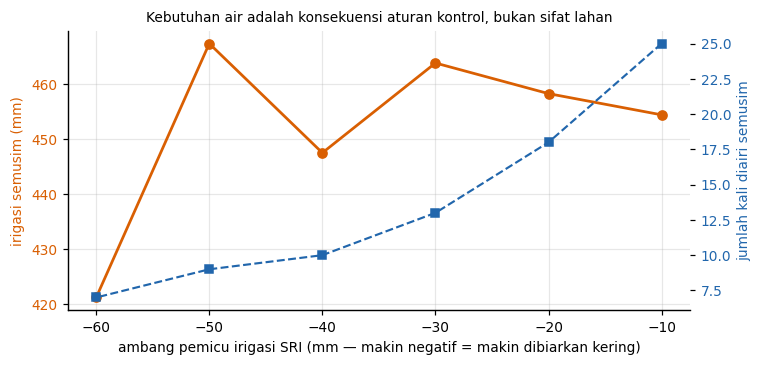

In [39]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(uji["pemicu_mm"], uji["irigasi_mm"], "o-", color="#d95f02", lw=1.8, ms=6)
ax.set_xlabel("ambang pemicu irigasi SRI (mm — makin negatif = makin dibiarkan kering)")
ax.set_ylabel("irigasi semusim (mm)", color="#d95f02")
ax.tick_params(axis="y", labelcolor="#d95f02")

ax2 = ax.twinx(); ax2.grid(False)
ax2.plot(uji["pemicu_mm"], uji["kali_diairi"], "s--", color="#2166ac", lw=1.4, ms=5)
ax2.set_ylabel("jumlah kali diairi semusim", color="#2166ac")
ax2.tick_params(axis="y", labelcolor="#2166ac")

ax.set_title("Kebutuhan air adalah konsekuensi aturan kontrol, bukan sifat lahan",
             fontsize=9)
plt.tight_layout(); plt.show()

### Ketidakpastian terbesar: perkolasi saat sawah tidak tergenang

Waktu permukaan sawah kering, apakah air berhenti meresap ke bawah? **Tidak.**
Tanah di bawahnya masih jenuh dan tetap menetes turun. Pertanyaannya: seberapa besar?

Angka ini **tidak diukur** di ketiga paper — Li hanya mengukur perkolasi saat tergenang.
Padahal justru angka inilah yang menentukan seberapa hemat SRI, karena SRI menghabiskan
sebagian besar musim dalam kondisi tidak tergenang.

Di bawah rasio ini digeser dari 0 (berhenti total — tidak masuk akal secara fisika)
sampai 0,75 (hampir sama derasnya dengan saat tergenang).

In [40]:
baris_pk = []
for rasio in (0.00, 0.15, 0.30, 0.45, 0.60, 0.75):
    tot = {}
    for rezim in ("FL", "SRI"):
        ir = pk = 0.0
        for _, p in petak.iterrows():
            sm = simulasi_petak(cuaca, rezim, p["perk_per_mm"], rasio_kering=rasio)
            bobot = p["luas_m2"] / LUAS_M2
            ir += sm["irigasi"].sum()   * bobot
            pk += sm["perkolasi"].sum() * bobot
        tot[rezim] = (ir, pk)
    baris_pk.append({
        "rasio_kering":   rasio,
        "FL_irigasi_mm":  tot["FL"][0],  "FL_perkolasi_mm":  tot["FL"][1],
        "SRI_irigasi_mm": tot["SRI"][0], "SRI_perkolasi_mm": tot["SRI"][1],
        "hemat_SRI_pct":  100*(tot["FL"][0]-tot["SRI"][0])/tot["FL"][0],
    })
pkt = pd.DataFrame(baris_pk)
print(pkt.to_string(index=False, float_format=lambda v: f"{v:,.1f}"))

lo, hi = pkt["hemat_SRI_pct"].min(), pkt["hemat_SRI_pct"].max()
print(f"\nPenghematan SRI berkisar {lo:.1f}% sampai {hi:.1f}% - HANYA karena satu angka")
print(f"yang belum pernah diukur. Nilai yang dipakai di notebook ini: "
      f"{PERK_KERING_RASIO:.2f} (perkiraan).")
print()
print("CARA MENGUKURNYA DI LAPANGAN:")
print("  Pasang sensor TMA, lalu baca laju penurunan air antara jam 22.00-04.00")
print("  pada malam tanpa hujan dan tanpa irigasi. Jam segitu penguapan hampir nol,")
print("  jadi seluruh penurunan air = perkolasi murni. Ulangi saat sawah tergenang")
print("  dan saat sawah kering -> rasionya langsung ketahuan.")
print()
print("  Syarat: sensor harus bisa baca perubahan <= 0,5 mm. Sensor ultrasonik murah")
print("  (ketelitian +/- 1 cm) tidak akan bisa. Ini menentukan pilihan hardware.")

 rasio_kering  FL_irigasi_mm  FL_perkolasi_mm  SRI_irigasi_mm  SRI_perkolasi_mm  hemat_SRI_pct
          0.0          443.3            134.8           335.4              53.7           24.3
          0.1          443.3            134.8           358.6              77.5           19.1
          0.3          443.3            134.8           371.6             103.1           16.2
          0.5          443.3            134.8           390.5             125.0           11.9
          0.6          443.3            134.8           407.3             148.4            8.1
          0.8          443.3            134.8           428.8             173.1            3.3

Penghematan SRI berkisar 3.3% sampai 24.3% - HANYA karena satu angka
yang belum pernah diukur. Nilai yang dipakai di notebook ini: 0.60 (perkiraan).

CARA MENGUKURNYA DI LAPANGAN:
  Pasang sensor TMA, lalu baca laju penurunan air antara jam 22.00-04.00
  pada malam tanpa hujan dan tanpa irigasi. Jam segitu penguapan hampir nol,
  ja

---
## 13. Ekspor hasil

Disimpan ke `note/output/` supaya bisa dipakai modul WMS berikutnya.

In [41]:
# Geometri petak dalam derajat (untuk dipetakan lagi nanti)
geo = []
for poly, (_, r) in zip(petak_poly, petak.iterrows()):
    geo.append({"id_petak": r["id_petak"], "luas_m2": round(r["luas_m2"], 2),
                "luas_ha": round(r["luas_ha"], 5),
                "cara_ambil_air": r["cara_ambil_air"],
                "koordinat": [[round(px/M_PER_DEG_LON + lon0, 8),
                               round(py/M_PER_DEG_LAT + lat0, 8)] for px, py in poly]})

berkas = {
    "petak.csv":          petak,
    "cuaca_harian.csv":   cuaca,
    "neraca_harian.csv":  harian,
    "ringkasan_petak.csv": ringkasan,
    "kebutuhan_air.csv":  keb,
    "water_loss.csv":     wl,
    "penyiapan_lahan.csv": pl,
}
for nama, df in berkas.items():
    df.to_csv(OUT_DIR / nama, index=False)
    print(f"  {nama:<22} {len(df):>6,} baris")

# KML berwarna sudah ditulis di bagian 11e
for k in sorted(OUT_DIR.glob("petak_*.kml")):
    print(f"  {k.name:<22} {k.stat().st_size:>6,} byte")

(OUT_DIR / "petak_geometri.json").write_text(
    json.dumps({"sumber_kml": KML.name, "crs": "EPSG:4326",
                "luas_total_m2": round(LUAS_M2, 2), "luas_total_ha": round(LUAS_HA, 5),
                "luas_total_km2": round(LUAS_KM2, 8), "petak": geo},
               indent=2, ensure_ascii=False), encoding="utf-8")
print(f"  {'petak_geometri.json':<22} {len(geo):>6,} petak")
print(f"\nSemua tersimpan di: {OUT_DIR}")

  petak.csv                  12 baris
  cuaca_harian.csv          110 baris
  neraca_harian.csv       2,640 baris
  ringkasan_petak.csv        24 baris
  kebutuhan_air.csv          24 baris
  water_loss.csv             24 baris
  penyiapan_lahan.csv        12 baris
  petak_kebutuhan_air.kml 14,183 byte
  petak_perkolasi.kml    14,058 byte
  petak_water_loss.kml   14,157 byte
  petak_geometri.json        12 petak

Semua tersimpan di: D:\WMS_AgrinIrigation\note\output


---
## 14. Ringkasan

In [42]:
fl  = keb[keb.rezim == "FL"]
sri = keb[keb.rezim == "SRI"]
irig_fl  = fl["irigasi_m3"].sum()  / (LUAS_M2/1000)
irig_sri = sri["irigasi_m3"].sum() / (LUAS_M2/1000)

print("=" * 70)
print("                        RINGKASAN HASIL")
print("=" * 70)
print(f"\n  LAHAN  (dari {KML.name})")
print(f"    Lokasi              : {lat0:.5f} LS, {lon0:.5f} BT  (Jawa Barat)")
print(f"    Luas                : {LUAS_M2:,.0f} m2  =  {LUAS_HA:.4f} ha  =  {LUAS_KM2:.6f} km2")
print(f"    Keliling            : {KELILING:,.0f} m")
print(f"    Dibagi jadi         : {len(petak)} petak "
      f"({petak['luas_ha'].min():.3f} - {petak['luas_ha'].max():.3f} ha)")

print(f"\n  KEBUTUHAN AIR  ({N_HARI} hari, hujan {cuaca['hujan_mm'].sum():.0f} mm)")
print(f"    {'':<22}{'FL (genangan)':>18}{'SRI':>18}")
print(f"    {'-'*58}")
for label, a, b in [
    ("Irigasi semusim (mm)", irig_fl, irig_sri),
    ("Irigasi semusim (m3)", fl["irigasi_m3"].sum(), sri["irigasi_m3"].sum()),
    ("NFR (mm/hari)",        irig_fl/N_HARI, irig_sri/N_HARI),
    ("DR (l/detik/ha)",      ke_l_detik_ha(irig_fl/N_HARI), ke_l_detik_ha(irig_sri/N_HARI)),
    ("Debit total (l/detik)",ke_l_detik_ha(irig_fl/N_HARI)*LUAS_HA,
                             ke_l_detik_ha(irig_sri/N_HARI)*LUAS_HA)]:
    print(f"    {label:<22}{a:>18,.2f}{b:>18,.2f}")
print(f"    {'Debit puncak (l/dt)':<22}{pl['debit_l_detik'].sum():>18,.2f}"
      f"{pl['debit_l_detik'].sum():>18,.2f}   <- penyiapan lahan")

print(f"\n  WATER LOSS")
print(f"    {'':<22}{'FL (mm)':>12}{'FL (%)':>10}{'SRI (mm)':>12}{'SRI (%)':>10}")
print(f"    {'-'*66}")
for nama, k in [("Menguap (ETc)", "etc"), ("Meresap (perkolasi)", "perkolasi"),
                ("Mengalir keluar", "limpasan")]:
    f_ = wl[wl.rezim == "FL"]; s_ = wl[wl.rezim == "SRI"]
    print(f"    {nama:<22}{f_[k+'_mm'].mean():>12.1f}{f_[k+'_pct'].mean():>9.1f}%"
          f"{s_[k+'_mm'].mean():>12.1f}{s_[k+'_pct'].mean():>9.1f}%")

hemat = 100*(irig_fl - irig_sri)/irig_fl
print(f"\n  SRI menghemat air {hemat:.1f}% dibanding genangan terus")
print(f"  (paper Arif mencatat penghematan 3,4% + hasil gabah naik 5,5%)")
print("\n" + "=" * 70)

                        RINGKASAN HASIL

  LAHAN  (dari dummy_ricepad.kml)
    Lokasi              : -7.18092 LS, 107.90995 BT  (Jawa Barat)
    Luas                : 45,627 m2  =  4.5627 ha  =  0.045627 km2
    Keliling            : 1,193 m
    Dibagi jadi         : 12 petak (0.051 - 0.691 ha)

  KEBUTUHAN AIR  (110 hari, hujan 216 mm)
                               FL (genangan)               SRI
    ----------------------------------------------------------
    Irigasi semusim (mm)              443.30            407.33
    Irigasi semusim (m3)           20,226.45         18,585.44
    NFR (mm/hari)                       4.03              3.70
    DR (l/detik/ha)                     0.72              0.66
    Debit total (l/detik)               3.27              3.01
    Debit puncak (l/dt)                10.46             10.46   <- penyiapan lahan

  WATER LOSS
                               FL (mm)    FL (%)    SRI (mm)   SRI (%)
    -----------------------------------------------

---
## 15. Daftar asumsi — **baca sebelum memakai angka di atas**

### Yang berasal dari data nyata (paper di `docs/`)

| Apa | Nilai | Sumber |
|---|---|---|
| Kc per fase, FL & SRI | 1,01 / 1,02 / 1,09 / 1,05 dan 1,00 / 0,96 / 1,02 / 1,04 | Arif, Tabel 1 |
| Rumus ETo Hargreaves | pers. (1) | Arif |
| Koefisien perkolasi `a` | 5,0e-7 / 1,6e-6 / 4,0e-7 per detik | Li, §2.3 |
| Rumus limpasan lubang buang | pers. (7)–(8) | Li |
| Tinggi pematang ±17 cm | `PZ1` = 168 mm | Chen, Tabel 3 |
| Rumus penyiapan lahan | van de Goor & Zijlstra | KP-01 |
| Efisiensi irigasi 0,65 | 0,90 × 0,90 × 0,80 | KP-01 |

### Yang **dikarang** dan perlu diganti data lapangan

| Asumsi | Dipakai | Pengaruhnya |
|---|---|---|
| **Cuaca 110 hari** | Dibangkitkan acak (seed 20260810) | **Besar.** Ganti dengan data BMKG / stasiun sendiri |
| **Pembagian 12 petak** | Strip melintang otomatis | Sedang. Petak asli tidak sejajar seperti ini |
| **Cara ambil air** | Dibagi 1/3 hulu-tengah-hilir | Sedang. Harus dari survei saluran nyata |
| **Panjang fase** 20/30/40/20 hari | Perkiraan untuk Ciherang ±110 hari | Sedang. Cek dengan penyuluh setempat |
| **Setpoint TMA per fase** | Dari deskripsi Arif §2.1 | Sedang |
| **Ambang pemicu SRI** −20/−25/−30 mm | Dari *maksud* Arif ("dijaga dekat permukaan tanah"), bukan dari TMA yang *terukur* | **Besar** — lihat bagian 12 |
| **Hujan: campuran ringan/lebat** | 85% rerata 6 mm, 15% rerata 32 mm | Sedang — menentukan seberapa sering melimpas |
| **Efisiensi 0,65** | Nilai umum KP-01 | Besar untuk DR — ukur sendiri kalau bisa |
| **`S` = 250 mm, `T` = 30 hari** (penyiapan lahan) | Nilai lazim | Besar untuk debit puncak |

### Penyederhanaan yang perlu disadari

1. **Perkolasi saat tidak tergenang** dipakai `PERK_KERING_RASIO = 0,60` — perkiraan,
   **bukan hasil ukur**. Ini ketidakpastian terbesar di notebook ini: menggesernya
   dari 0 ke 0,75 mengubah penghematan SRI dari ~24% jadi ~5% (lihat bagian 12).
   Cara mengukurnya ada di bagian 12 — baca laju surut TMA jam 22.00–04.00.
2. **Limpasan habis dalam sehari.** Sudah diuji dengan rumus ambang Li: kelebihan 5 cm
   terkuras < 24 jam. Aman untuk langkah waktu harian, **tidak** aman kalau nanti mau
   simulasi per jam.
3. **Tidak ada faktor cekaman air terpisah.** Kc dari Arif dihitung mundur dari neraca
   lapangan, jadi efek kekeringan sudah terkandung. Menambah faktor cekaman = hitung dua kali.
4. **Tiap petak berdiri sendiri.** Limpasan petak atas **belum** dialirkan ke petak bawah.
   Untuk *tagoshi* (sistem estafet) ini belum benar — perlu model kaskade seperti Li.
5. **Tidak ada kehilangan di saluran** antar petak. Hanya diwakili angka efisiensi 0,65.
6. **Lahan dianggap datar** untuk hitungan luas. Luas sebenarnya di permukaan miring
   sedikit lebih besar — untuk sawah terasering yang tiap petaknya datar, ini justru benar.

### Langkah berikutnya

- [ ] Ganti cuaca dummy dengan data stasiun / BMKG
- [ ] Ganti pembagian petak dengan poligon hasil survei
- [ ] Tambah **kaskade antar petak** (limpasan hulu jadi masukan hilir) — pers. (5) Li
- [ ] Tambah prediksi panen berbasis akumulasi panas (GDD)
- [ ] Tambah neraca nitrogen, ikut limpasan & perkolasi